# Feature Engineering & Data Understanding Pipeline

This notebook builds a reproducible, competition-ready feature pipeline for predicting `is_correct`.
It validates the merged data, investigates predictive structure, parses long tutoring conversations,
creates target-independent features, checks outliers and collinearity, and exports model-ready artifacts.

**Design principles**

- No feature is calculated from `is_correct`.
- Expensive transcript analysis runs once per unique session transcript and is merged back to responses.
- Raw and cleaned text are retained for sparse text models and Transformers.
- Aggregate frequency features are unsupervised. For strict cross-validation, fit their mappings on each
  training fold and apply them to the validation fold.
- Figures include a short, data-driven interpretation directly below the plot.

## 1. Setup and reproducibility

In [1]:
from __future__ import annotations

import gc
import re
import string
import unicodedata
import warnings
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
TARGET = "is_correct"
EXPECTED_COLUMNS = [
    "response_id",
    "session_id",
    "learning_objective_id",
    "learning_objective",
    TARGET,
    "transcript",
]

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "figure.dpi": 110,
    }
)


def memory_mb(frame: pd.DataFrame) -> float:
    '''Return deep DataFrame memory usage in MiB.'''
    return frame.memory_usage(index=True, deep=True).sum() / (1024**2)


def print_insight(title: str, message: str) -> None:
    '''Print a consistent interpretation after a table or visualization.'''
    print(f"\n{title}: {message}")

## 2. Load the merged parquet dataset

In [2]:
def resolve_data_path() -> Path:
    '''Find the merged parquet whether the notebook runs from the project root or `eda/`.'''
    candidates = [
        Path("eda/train_merged.parquet"),
        Path("train_merged.parquet"),
        Path("../eda/train_merged.parquet"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = "\n".join(f"  - {path.resolve()}" for path in candidates)
    raise FileNotFoundError(f"Could not find train_merged.parquet. Searched:\n{searched}")


DATA_PATH = resolve_data_path()
df = pd.read_parquet(DATA_PATH)

original_shape = df.shape
memory_before_mb = memory_mb(df)

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {original_shape[0]:,} rows x {original_shape[1]:,} columns")
print(f"Deep memory usage: {memory_before_mb:,.2f} MiB")
display(df.head(3))

Loaded: D:\Competition\Trace-The-Race-Competition\notebook\eda\train_merged.parquet
Shape: 35,072 rows x 6 columns
Deep memory usage: 1,592.74 MiB


,response_id,session_id,learning_objective_id,learning_objective,is_correct,transcript
0,aaaavsh,bcaufvc,dqibnvd,Knowing the value of each digit in numbers with up to 2 decimal places.,1.0000,"[00:00:00] background: [unclear]\n[00:00:00] tutor: Miss, I can't hear.\n[00:00:04] tutor: Can you hear me? [unclear..."
1,aaabhzi,eyutanf,eukmzxl,Adding and subtracting tens to a 2-digit number.,1.0000,[00:00:00] tutor: Yay! Hello!\n[00:00:02] student: Hello.\n[00:00:04] tutor: Hello.\n[00:00:07] student: Hello.\n[00...
2,aaahpnz,juptkxd,fjbqcsv,Comparing and ordering fractions by finding a common denominator.,0.0000,[00:00:00] background: [unclear]\n[00:00:00] tutor: Is it me you are looking for?\n[00:00:01] student: Hello.\n[00:0...


## 3. Data validation

In [3]:
def validate_dataset(frame: pd.DataFrame) -> dict[str, Any]:
    '''Validate schema, identifiers, target values, duplicates, and session consistency.'''
    missing_columns = sorted(set(EXPECTED_COLUMNS) - set(frame.columns))
    unexpected_columns = sorted(set(frame.columns) - set(EXPECTED_COLUMNS))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    duplicate_rows = int(frame.duplicated().sum())
    duplicate_response_ids = int(frame["response_id"].duplicated(keep=False).sum())
    duplicate_session_ids = int(frame["session_id"].duplicated(keep=False).sum())
    target_values = sorted(frame[TARGET].dropna().unique().tolist())

    if not set(target_values).issubset({0, 1, 0.0, 1.0}):
        raise ValueError(f"Target contains unexpected values: {target_values}")

    transcript_per_session = frame.groupby("session_id", observed=True)["transcript"].nunique(dropna=False)
    objective_label_per_id = frame.groupby("learning_objective_id", observed=True)[
        "learning_objective"
    ].nunique(dropna=False)

    report = {
        "rows": len(frame),
        "columns": frame.shape[1],
        "unexpected_columns": unexpected_columns,
        "duplicate_rows": duplicate_rows,
        "duplicate_response_id_rows": duplicate_response_ids,
        "repeated_session_id_rows_expected": duplicate_session_ids,
        "sessions_with_multiple_transcripts": int((transcript_per_session > 1).sum()),
        "objective_ids_with_multiple_labels": int((objective_label_per_id > 1).sum()),
        "target_values": target_values,
        "memory_mib": memory_mb(frame),
    }
    return report


validation_report = validate_dataset(df)
validation_table = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
        "unique_including_na": df.nunique(dropna=False),
    }
)

display(pd.Series(validation_report, name="value").to_frame())
display(validation_table)

assert validation_report["duplicate_response_id_rows"] == 0, (
    "`response_id` must uniquely identify a training row. Resolve duplicates before modeling."
)
assert validation_report["objective_ids_with_multiple_labels"] == 0, (
    "A learning_objective_id maps to multiple labels; inspect this data integrity issue."
)

if validation_report["duplicate_rows"]:
    print("Warning: exact duplicate rows exist. They are reported but not silently removed.")
if validation_report["sessions_with_multiple_transcripts"]:
    print("Warning: some sessions map to multiple transcripts; the longest transcript will be retained.")

print_insight(
    "Dataset Insight",
    f"The table contains {len(df):,} response rows, "
    f"{df['session_id'].nunique():,} sessions, and "
    f"{df['learning_objective_id'].nunique():,} learning objectives. "
    "Repeated session IDs are expected because a session can contain multiple scored responses.",
)

,value
rows,35072
columns,6
unexpected_columns,[]
duplicate_rows,0
duplicate_response_id_rows,0
repeated_session_id_rows_expected,20615
sessions_with_multiple_transcripts,0
objective_ids_with_multiple_labels,0
target_values,"[0.0, 1.0]"
memory_mib,"2,385.2389"


,dtype,missing,missing_pct,unique_including_na
response_id,object,0,0.0000,35072
session_id,object,0,0.0000,22821
learning_objective_id,object,0,0.0000,398
learning_objective,object,0,0.0000,398
is_correct,float64,0,0.0000,2
transcript,object,0,0.0000,22821



Dataset Insight: The table contains 35,072 response rows, 22,821 sessions, and 398 learning objectives. Repeated session IDs are expected because a session can contain multiple scored responses.


### Dataset Insight

Identifier duplication is interpreted by column semantics: `response_id` should be unique, while
`session_id` should repeat. A session-to-transcript consistency check is more useful than treating
repeated sessions as erroneous duplicates. Missing targets, non-binary labels, conflicting objective
labels, and duplicate response IDs are treated as blocking data-quality issues.

## 4. Memory-aware dtype normalization

In [4]:
def optimize_base_dtypes(frame: pd.DataFrame) -> pd.DataFrame:
    '''Reduce memory without changing values or category semantics.'''
    optimized = frame.copy()
    for column in ["response_id", "session_id", "learning_objective_id", "transcript"]:
        optimized[column] = optimized[column].astype("string[pyarrow]")
    optimized["learning_objective"] = optimized["learning_objective"].astype("category")
    optimized[TARGET] = optimized[TARGET].astype("Int8")
    return optimized


df = optimize_base_dtypes(df)
print(f"Memory after base dtype optimization: {memory_mb(df):,.2f} MiB")

Memory after base dtype optimization: 794.55 MiB


## 5. Target analysis

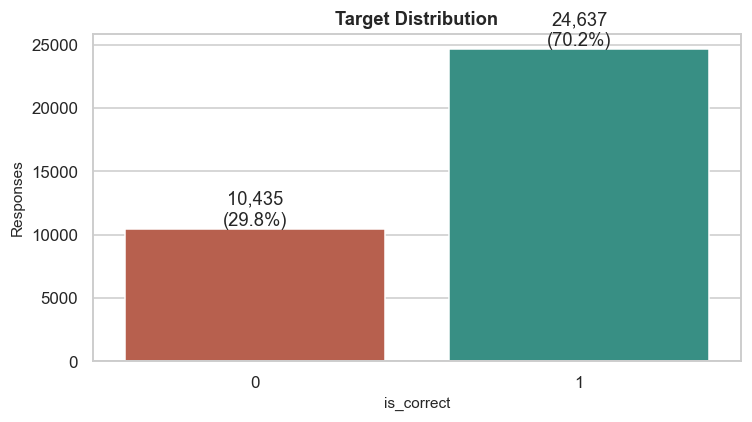


Target Insight: The minority class represents 29.8% of responses (majority/minority ratio 2.36). Use stratified folds and class-aware metrics such as ROC-AUC, PR-AUC, or balanced accuracy.


In [5]:
target_counts = df[TARGET].value_counts().sort_index()
target_pct = df[TARGET].value_counts(normalize=True).sort_index().mul(100)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values,
    palette=["#C8553D", "#2A9D8F"],
    ax=ax,
)
ax.set(title="Target Distribution", xlabel="is_correct", ylabel="Responses")
for index, value in enumerate(target_counts.values):
    ax.text(index, value, f"{value:,}\n({target_pct.iloc[index]:.1f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()

minority_share = target_pct.min()
imbalance_ratio = target_counts.max() / max(target_counts.min(), 1)
print_insight(
    "Target Insight",
    f"The minority class represents {minority_share:.1f}% of responses "
    f"(majority/minority ratio {imbalance_ratio:.2f}). "
    + (
        "Use stratified folds and class-aware metrics such as ROC-AUC, PR-AUC, or balanced accuracy."
        if minority_share < 40
        else "The target is reasonably balanced, but stratified validation is still recommended."
    ),
)

### Target Insight

Class balance determines whether plain accuracy is trustworthy. Target values are used only for
diagnostics and later model evaluation; they are never used to create an input feature.

## 6. Learning-objective and session distributions

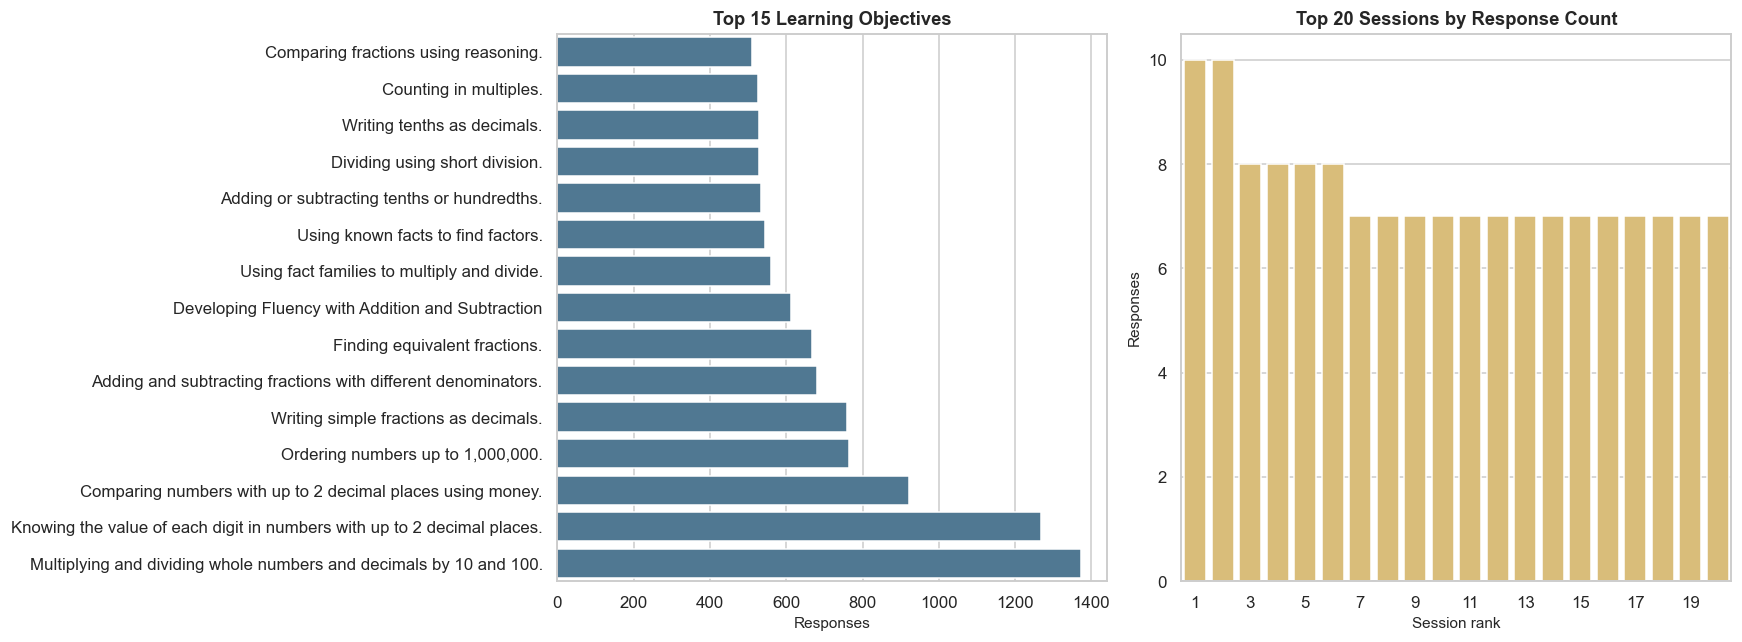


Learning Objective Insight: The ten most frequent objectives cover 23.2% of responses. Frequency may encode curriculum exposure and objective difficulty, but rare objectives need robust handling.

Session Distribution Insight: 58.8% of response rows belong to sessions with multiple scored responses. Group-aware validation by session is important because rows from one transcript are not independent.


In [6]:
objective_counts = df["learning_objective"].value_counts()
session_counts = df["session_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_objectives = objective_counts.head(15).sort_values()
sns.barplot(
    x=top_objectives.values,
    y=[str(label)[:72] for label in top_objectives.index],
    color="#457B9D",
    ax=axes[0],
)
axes[0].set(title="Top 15 Learning Objectives", xlabel="Responses", ylabel="")

top_sessions = session_counts.head(20)
sns.barplot(
    x=np.arange(len(top_sessions)),
    y=top_sessions.values,
    color="#E9C46A",
    ax=axes[1],
)
axes[1].set(
    title="Top 20 Sessions by Response Count",
    xlabel="Session rank",
    ylabel="Responses",
)
axes[1].set_xticks(np.arange(0, len(top_sessions), 2))
axes[1].set_xticklabels(np.arange(1, len(top_sessions) + 1, 2))
plt.tight_layout()
plt.show()

top_objective_share = objective_counts.head(10).sum() / len(df) * 100
multi_response_session_share = session_counts[session_counts > 1].sum() / len(df) * 100
print_insight(
    "Learning Objective Insight",
    f"The ten most frequent objectives cover {top_objective_share:.1f}% of responses. "
    "Frequency may encode curriculum exposure and objective difficulty, but rare objectives need robust handling.",
)
print_insight(
    "Session Distribution Insight",
    f"{multi_response_session_share:.1f}% of response rows belong to sessions with multiple scored responses. "
    "Group-aware validation by session is important because rows from one transcript are not independent.",
)

### Learning Objective Insight

Objective dominance can create strong priors even without target encoding. `objective_frequency` and
`objective_popularity` may help tree models recognize common versus rare curriculum concepts. They
must not be confused with objective-level correctness rates, which would leak label information unless
carefully generated out of fold.

### Session Insight

Responses sharing a session also share transcript context. A random row split can place the same
conversation in training and validation, producing optimistic scores. Prefer `GroupKFold` or
`StratifiedGroupKFold` with `session_id` as the group.

## 7. Transcript parsing, cleaning, and quality statistics

In [7]:
TIMESTAMP_RE = re.compile(r"\[(\d{1,2}):(\d{2}):(\d{2})(?:\.\d+)?\]")
TURN_LINE_RE = re.compile(
    r"^\s*(?:\[\d{1,2}:\d{2}:\d{2}(?:\.\d+)?\]\s*)?"
    r"(tutor|student|background)\s*:\s*(.*)$",
    flags=re.IGNORECASE,
)
WORD_RE = re.compile(r"\b[\w']+\b", flags=re.UNICODE)
SENTENCE_RE = re.compile(r"[.!?]+")
UNCLEAR_RE = re.compile(r"\bunclear\b", flags=re.IGNORECASE)
SPEAKER_PREFIX_RE = re.compile(
    r"(?im)^\s*(?:tutor|student|background)\s*:\s*"
)
BRACKET_METADATA_RE = re.compile(r"\[[^\]]+\]")
MULTISPACE_RE = re.compile(r"\s+")
STANDARD_TEXT_RE = re.compile(r"[^a-z0-9\s.!?']")


def timestamp_to_seconds(parts: tuple[str, str, str]) -> float:
    hours, minutes, seconds = parts
    return int(hours) * 3600 + int(minutes) * 60 + float(seconds)


def normalize_transcript_text(text: str) -> str:
    '''Create a conservative model text: normalized case, no timestamps/metadata, useful punctuation retained.'''
    text = unicodedata.normalize("NFKC", text)
    text = TIMESTAMP_RE.sub(" ", text)
    text = SPEAKER_PREFIX_RE.sub(" ", text)
    text = BRACKET_METADATA_RE.sub(" ", text)
    text = text.lower().replace("—", " ").replace("–", " ")
    text = STANDARD_TEXT_RE.sub(" ", text)
    return MULTISPACE_RE.sub(" ", text).strip()


def safe_divide(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else 0.0


def analyze_transcript(raw_text: Any) -> dict[str, Any]:
    '''Extract all transcript statistics in one pass to minimize repeated scans of long conversations.'''
    raw = "" if pd.isna(raw_text) else str(raw_text)
    normalized_raw = unicodedata.normalize("NFKC", raw)

    speaker_counts = {"tutor": 0, "student": 0, "background": 0}
    utterances: list[str] = []
    for line in normalized_raw.splitlines():
        match = TURN_LINE_RE.match(line)
        if match:
            speaker = match.group(1).lower()
            speaker_counts[speaker] += 1
            utterances.append(match.group(2))

    if not utterances:
        fallback = TIMESTAMP_RE.sub(" ", normalized_raw)
        fallback = SPEAKER_PREFIX_RE.sub(" ", fallback)
        utterances = [fallback]

    content = " ".join(utterances)
    words = WORD_RE.findall(content)
    word_count = len(words)
    unique_word_count = len({word.lower() for word in words})
    sentence_count = len(SENTENCE_RE.findall(content))
    if word_count and sentence_count == 0:
        sentence_count = 1

    timestamps = [
        timestamp_to_seconds(match.groups())
        for match in TIMESTAMP_RE.finditer(normalized_raw)
    ]
    duration_sec = max(timestamps) - min(timestamps) if timestamps else 0.0

    tutor_turns = speaker_counts["tutor"]
    student_turns = speaker_counts["student"]
    background_turns = speaker_counts["background"]
    total_turns = tutor_turns + student_turns + background_turns
    tutor_student_turns = tutor_turns + student_turns

    punctuation_count = sum(char in string.punctuation for char in content)
    uppercase_count = sum(char.isupper() for char in content)
    digit_count = sum(char.isdigit() for char in content)
    total_word_chars = sum(len(word) for word in words)
    unclear_count = len(UNCLEAR_RE.findall(normalized_raw))
    question_count = content.count("?")
    exclamation_count = content.count("!")

    return {
        "clean_transcript": normalize_transcript_text(content),
        "char_count": len(content),
        "word_count": word_count,
        "sentence_count": sentence_count,
        "avg_sentence_length": safe_divide(word_count, sentence_count),
        "avg_word_length": safe_divide(total_word_chars, word_count),
        "unique_word_count": unique_word_count,
        "unique_word_ratio": safe_divide(unique_word_count, word_count),
        "vocabulary_richness": safe_divide(unique_word_count, word_count),
        "lexical_diversity": safe_divide(unique_word_count, np.sqrt(max(word_count, 1))),
        "punctuation_count": punctuation_count,
        "uppercase_count": uppercase_count,
        "digit_count": digit_count,
        "tutor_turns": tutor_turns,
        "student_turns": student_turns,
        "background_turns": background_turns,
        "total_turns": total_turns,
        "tutor_student_ratio": safe_divide(tutor_turns, student_turns),
        "avg_words_per_turn": safe_divide(word_count, total_turns),
        "unclear_count": unclear_count,
        "question_count": question_count,
        "exclamation_count": exclamation_count,
        "response_density": safe_divide(student_turns, total_turns),
        "duration_sec": duration_sec,
        "student_ratio": safe_divide(student_turns, total_turns),
        "tutor_ratio": safe_divide(tutor_turns, total_turns),
        "speaker_balance": 1.0
        - safe_divide(abs(tutor_turns - student_turns), tutor_student_turns),
        "transcript_density": safe_divide(word_count, duration_sec),
        "question_density": safe_divide(question_count, word_count),
        "unclear_density": safe_divide(unclear_count, total_turns),
    }

In [8]:
def build_session_text_features(frame: pd.DataFrame) -> pd.DataFrame:
    '''Analyze the longest available transcript once for every unique session.'''
    session_text = frame[["session_id", "transcript"]].copy()
    session_text["_raw_char_count"] = session_text["transcript"].str.len()
    session_text = (
        session_text.sort_values("_raw_char_count", ascending=False)
        .drop_duplicates("session_id", keep="first")
        .drop(columns="_raw_char_count")
        .reset_index(drop=True)
    )

    records: list[dict[str, Any]] = []
    total = len(session_text)
    for row_number, row in enumerate(session_text.itertuples(index=False), start=1):
        record = analyze_transcript(row.transcript)
        record["session_id"] = row.session_id
        records.append(record)
        if row_number % 2500 == 0 or row_number == total:
            print(f"Parsed {row_number:,}/{total:,} unique session transcripts")

    result = pd.DataFrame.from_records(records)
    result["session_id"] = result["session_id"].astype("string[pyarrow]")
    result["clean_transcript"] = result["clean_transcript"].astype("string[pyarrow]")
    return result


session_text_features = build_session_text_features(df)
display(session_text_features.head())
print(f"Session-level feature table: {session_text_features.shape}")
gc.collect()

Parsed 2,500/22,821 unique session transcripts


Parsed 5,000/22,821 unique session transcripts


Parsed 7,500/22,821 unique session transcripts


Parsed 10,000/22,821 unique session transcripts


Parsed 12,500/22,821 unique session transcripts


...

Parsed 22,500/22,821 unique session transcripts


Parsed 22,821/22,821 unique session transcripts


,clean_transcript,char_count,word_count,sentence_count,avg_sentence_length,avg_word_length,unique_word_count,unique_word_ratio,vocabulary_richness,lexical_diversity,punctuation_count,uppercase_count,digit_count,tutor_turns,student_turns,background_turns,total_turns,tutor_student_ratio,avg_words_per_turn,unclear_count,question_count,exclamation_count,response_density,duration_sec,student_ratio,tutor_ratio,speaker_balance,transcript_density,question_density,unclear_density,session_id
0,hello? hello? hello tobias. hi. hi how are you doing? hello? hello can you hear me? yeah i can able to hear you tobi...,45026,8663,1037,8.3539,3.9619,662,0.0764,0.0764,7.1125,2375,1352,839,227,227,17,471,1.0000,18.3928,96,322,2,0.4820,"3,721.0000",0.4820,0.4820,1.0000,2.3281,0.0372,0.2038,eafvzsi
1,hello? hello? hello desmond can you hear me? yeah. alright desmond so it's been almost a week since we met and worke...,35766,6768,835,8.1054,4.0164,610,0.0901,0.0901,7.4148,2071,1196,538,238,212,12,462,1.1226,14.6494,55,257,4,0.4589,"2,719.0000",0.4589,0.5152,0.9422,2.4892,0.0380,0.1190,cajcyru
2,hi callum. hello. i can't really hear you. could you pull your mic closer? hello. hi hi. welcome back callum. how ar...,34599,6977,855,8.1602,3.7129,619,0.0887,0.0887,7.4106,1957,1101,1058,226,210,17,453,1.0762,15.4018,66,280,0,0.4636,"2,808.0000",0.4636,0.4989,0.9633,2.4847,0.0401,0.1457,jkkhyiu
3,hello? hello. hi. yeah. awesome. so is this tamsin? yeah. awesome then. so how are you doing today tamsin? i will th...,31597,6353,1074,5.9153,3.7057,562,0.0885,0.0885,7.0509,1953,1222,289,292,295,13,600,0.9898,10.5883,51,372,0,0.4917,"2,681.0000",0.4917,0.4867,0.9949,2.3696,0.0586,0.0850,dwcgsqm
4,hello. hi. hi lachlan. can you hear me? yeah i can thanks. brilliant. it's been a while. yeah i'm so sorry. i've had...,33848,6472,891,7.2637,3.9750,747,0.1154,0.1154,9.2854,2048,1089,585,214,219,38,471,0.9772,13.7410,60,208,0,0.4650,"2,692.0000",0.4650,0.4544,0.9885,2.4042,0.0321,0.1274,kghgtbb


Session-level feature table: (22821, 31)


29

### Transcript Insight

The parser separates spoken content from timestamps and speaker labels before calculating language
statistics. The cleaned text keeps educational vocabulary, apostrophes, and sentence punctuation,
while removing timestamps, bracket metadata, unusual symbols, repeated whitespace, and case noise.
`[unclear]` is counted before cleaning so audio/transcription quality remains available as a feature.

## 8. Transcript length and language distributions

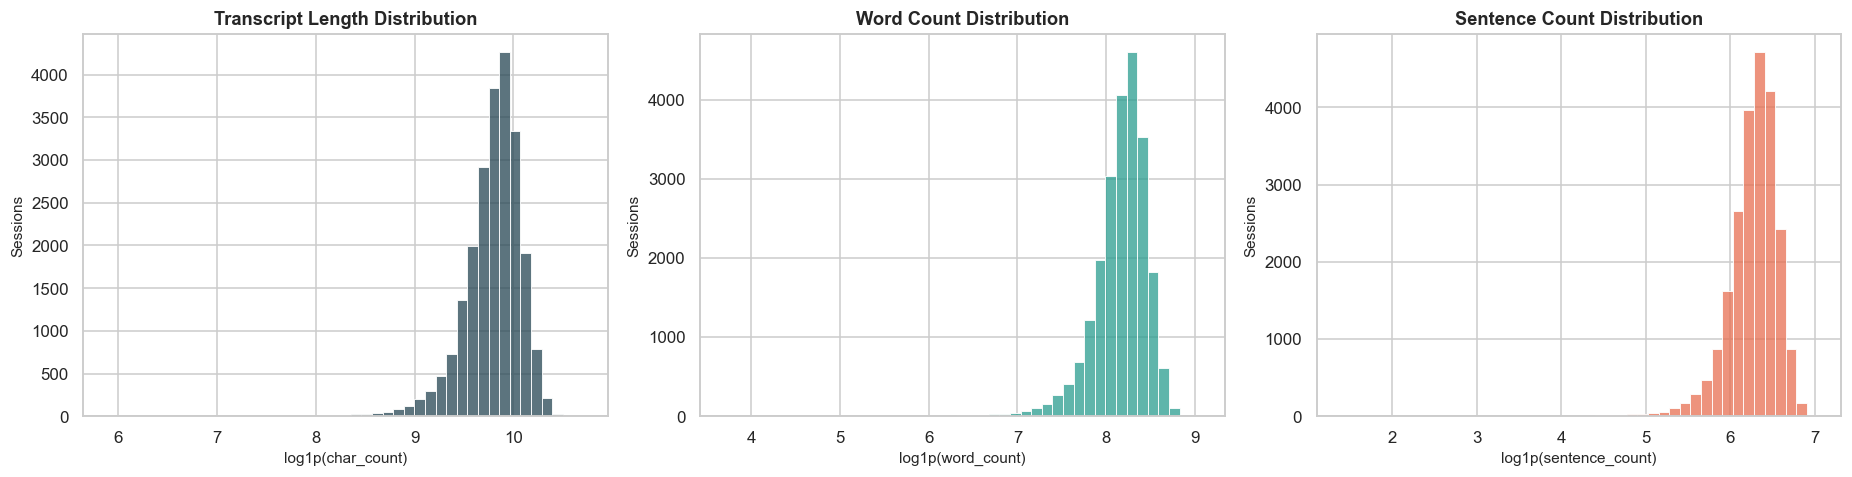


Transcript Length Insight: The median session contains 3,681 words and the 95th percentile is 5,160; 0.0% contain fewer than 100 words. Log scaling exposes the heavy tail. Very short transcripts may lack evidence, while very long transcripts may dilute the response-relevant context and require truncation for Transformers.


In [9]:
plot_features = session_text_features[
    ["char_count", "word_count", "sentence_count", "avg_word_length"]
].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, column, title, color in zip(
    axes,
    ["char_count", "word_count", "sentence_count"],
    ["Transcript Length", "Word Count", "Sentence Count"],
    ["#264653", "#2A9D8F", "#E76F51"],
):
    sns.histplot(np.log1p(plot_features[column]), bins=45, color=color, ax=ax)
    ax.set(title=f"{title} Distribution", xlabel=f"log1p({column})", ylabel="Sessions")
plt.tight_layout()
plt.show()

word_median = session_text_features["word_count"].median()
word_p95 = session_text_features["word_count"].quantile(0.95)
short_share = session_text_features["word_count"].lt(100).mean() * 100
print_insight(
    "Transcript Length Insight",
    f"The median session contains {word_median:,.0f} words and the 95th percentile is "
    f"{word_p95:,.0f}; {short_share:.1f}% contain fewer than 100 words. "
    "Log scaling exposes the heavy tail. Very short transcripts may lack evidence, while very long "
    "transcripts may dilute the response-relevant context and require truncation for Transformers.",
)

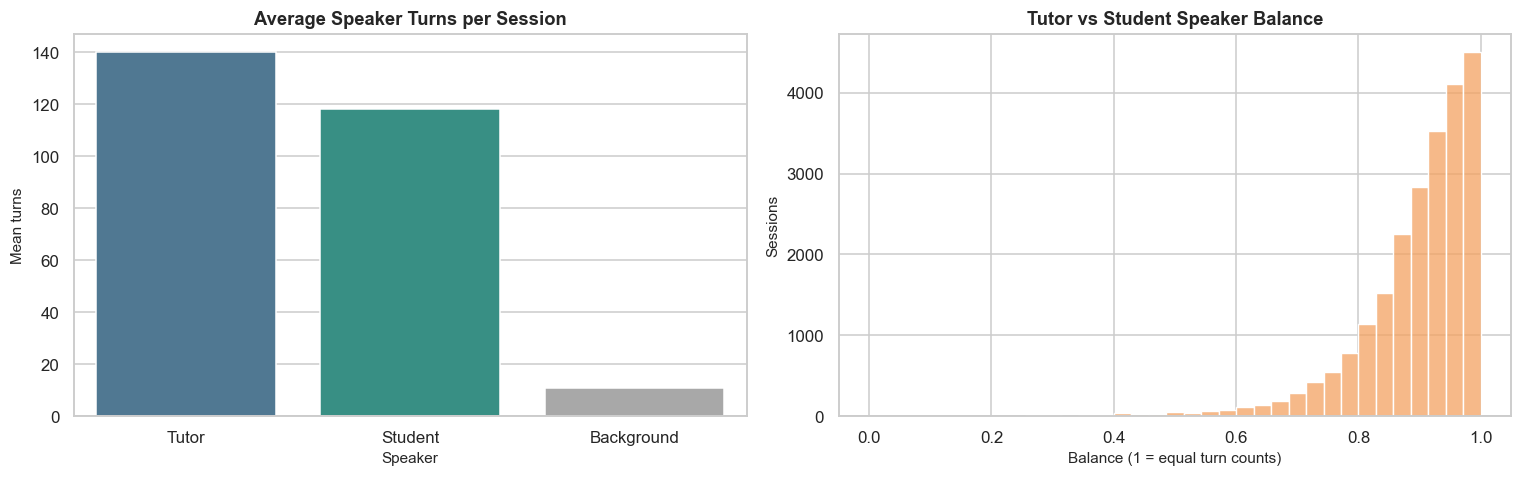


Turn Distribution Insight: The median student-turn share is 0.45, and 1.0% of sessions have speaker balance below 0.5. Strong speaker imbalance can indicate lecture-heavy, incomplete, or mislabeled conversations and may affect the evidence available for correctness.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

turn_means = session_text_features[
    ["tutor_turns", "student_turns", "background_turns"]
].mean().rename(
    {
        "tutor_turns": "Tutor",
        "student_turns": "Student",
        "background_turns": "Background",
    }
)
sns.barplot(
    x=turn_means.index,
    y=turn_means.values,
    palette=["#457B9D", "#2A9D8F", "#A8A8A8"],
    ax=axes[0],
)
axes[0].set(title="Average Speaker Turns per Session", xlabel="Speaker", ylabel="Mean turns")

sns.histplot(
    session_text_features["speaker_balance"],
    bins=35,
    color="#F4A261",
    ax=axes[1],
)
axes[1].set(
    title="Tutor vs Student Speaker Balance",
    xlabel="Balance (1 = equal turn counts)",
    ylabel="Sessions",
)
plt.tight_layout()
plt.show()

median_student_ratio = session_text_features["student_ratio"].median()
low_balance_share = session_text_features["speaker_balance"].lt(0.5).mean() * 100
print_insight(
    "Turn Distribution Insight",
    f"The median student-turn share is {median_student_ratio:.2f}, and {low_balance_share:.1f}% "
    "of sessions have speaker balance below 0.5. Strong speaker imbalance can indicate lecture-heavy, "
    "incomplete, or mislabeled conversations and may affect the evidence available for correctness.",
)

In [11]:
quality_summary = session_text_features[
    [
        "duration_sec",
        "avg_words_per_turn",
        "unclear_count",
        "question_count",
        "exclamation_count",
        "response_density",
        "transcript_density",
    ]
].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
display(quality_summary)

zero_duration_share = session_text_features["duration_sec"].eq(0).mean() * 100
unclear_share = session_text_features["unclear_count"].gt(0).mean() * 100
print_insight(
    "Conversation Quality Insight",
    f"{unclear_share:.1f}% of sessions contain at least one unclear marker and "
    f"{zero_duration_share:.1f}% have no usable timestamp span. "
    "Unclear density may identify noisy audio; zero duration should be treated as missing timing evidence, "
    "not as a genuinely instantaneous session.",
)

,count,mean,std,min,5%,25%,50%,75%,95%,max
duration_sec,"22,821.0000","2,485.5175",332.7295,205.0000,"1,830.0000","2,351.0000","2,603.0000","2,705.0000","2,793.0000","3,721.0000"
avg_words_per_turn,"22,821.0000",13.9417,3.4436,1.6250,9.4983,11.6316,13.4161,15.6689,20.0474,58.8947
unclear_count,"22,821.0000",83.2986,20.0638,7.0000,53.0000,71.0000,83.0000,95.0000,116.0000,462.0000
question_count,"22,821.0000",147.0789,51.7354,0.0000,70.0000,111.0000,143.0000,179.0000,238.0000,417.0000
exclamation_count,"22,821.0000",1.6146,2.9685,0.0000,0.0000,0.0000,1.0000,2.0000,7.0000,74.0000
response_density,"22,821.0000",0.4352,0.0587,0.0000,0.3289,0.4100,0.4455,0.4728,0.5056,0.8101
transcript_density,"22,821.0000",1.4638,0.3200,0.0450,0.9200,1.2727,1.4730,1.6706,1.9726,2.5773



Conversation Quality Insight: 100.0% of sessions contain at least one unclear marker and 0.0% have no usable timestamp span. Unclear density may identify noisy audio; zero duration should be treated as missing timing evidence, not as a genuinely instantaneous session.


## 9. Learning-objective and session features

In [12]:
def add_aggregate_features(
    frame: pd.DataFrame,
    session_features: pd.DataFrame,
) -> pd.DataFrame:
    '''Merge session text features and add target-independent frequency/context aggregates.'''
    result = frame.merge(
        session_features,
        on="session_id",
        how="left",
        validate="many_to_one",
    )

    objective_frequency = result.groupby(
        "learning_objective_id", observed=True
    )["response_id"].transform("size")
    responses_per_objective = result.groupby(
        "learning_objective_id", observed=True
    )["response_id"].transform("nunique")
    responses_per_session = result.groupby(
        "session_id", observed=True
    )["response_id"].transform("size")
    session_objective_diversity = result.groupby(
        "session_id", observed=True
    )["learning_objective_id"].transform("nunique")

    result["objective_frequency"] = objective_frequency.astype("int32")
    result["objective_popularity"] = (objective_frequency / len(result)).astype("float32")
    result["responses_per_objective"] = responses_per_objective.astype("int32")
    result["responses_per_session"] = responses_per_session.astype("int16")
    result["session_transcript_length"] = result["char_count"].astype("int32")
    result["session_average_response_length"] = (
        result["word_count"] / responses_per_session.clip(lower=1)
    ).astype("float32")
    result["session_objective_diversity"] = session_objective_diversity.astype("int16")

    return result


engineered_df = add_aggregate_features(df, session_text_features)
display(
    engineered_df[
        [
            "objective_frequency",
            "objective_popularity",
            "responses_per_objective",
            "responses_per_session",
            "session_transcript_length",
            "session_average_response_length",
            "session_objective_diversity",
        ]
    ].describe().T
)

print_insight(
    "Learning Objective Insight",
    "Frequency and popularity expose whether an objective is common or rare without using correctness. "
    "This can help tree models learn different confidence regimes for well-represented versus sparse objectives.",
)
print_insight(
    "Session Insight",
    "Responses per session, transcript length per response, and objective diversity summarize conversation "
    "workload and scope. Large, diverse sessions may contain more context but can also be noisier.",
)

,count,mean,std,min,25%,50%,75%,max
objective_frequency,"35,072.0000",432.5188,331.5146,1.0000,205.0000,393.0000,530.0000,"1,373.0000"
objective_popularity,"35,072.0000",0.0123,0.0095,0.0000,0.0058,0.0112,0.0151,0.0391
responses_per_objective,"35,072.0000",432.5188,331.5146,1.0000,205.0000,393.0000,530.0000,"1,373.0000"
responses_per_session,"35,072.0000",2.0149,1.1580,1.0000,1.0000,2.0000,3.0000,10.0000
session_transcript_length,"35,072.0000","18,525.1523","4,660.5442",360.0000,"15,567.7500","18,634.0000","21,545.0000","45,026.0000"
session_average_response_length,"35,072.0000","2,371.7190","1,300.3400",19.5000,"1,317.7292","2,029.0000","3,413.0000","8,663.0000"
session_objective_diversity,"35,072.0000",2.0149,1.1580,1.0000,1.0000,2.0000,3.0000,10.0000



Learning Objective Insight: Frequency and popularity expose whether an objective is common or rare without using correctness. This can help tree models learn different confidence regimes for well-represented versus sparse objectives.

Session Insight: Responses per session, transcript length per response, and objective diversity summarize conversation workload and scope. Large, diverse sessions may contain more context but can also be noisier.


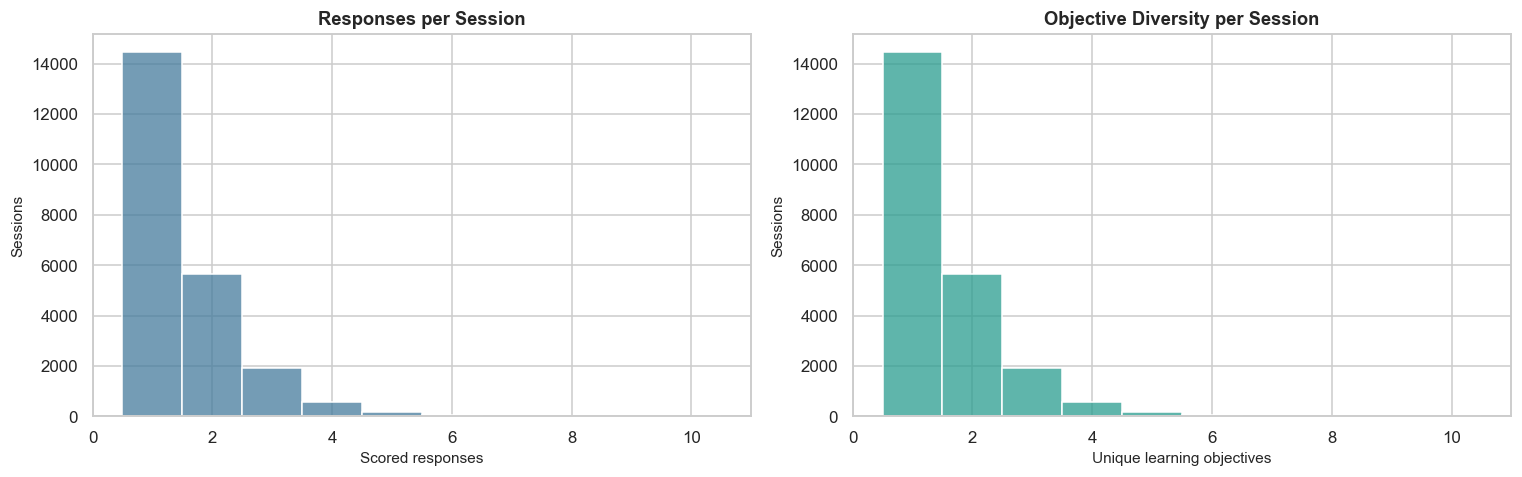


Response per Session Insight: The median session contributes 1 scored response(s); 3.6% of sessions span more than three objectives. Sessions with many labels should remain intact within a single validation fold.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(
    engineered_df[["session_id", "responses_per_session"]]
    .drop_duplicates("session_id")["responses_per_session"],
    discrete=True,
    color="#457B9D",
    ax=axes[0],
)
axes[0].set(
    title="Responses per Session",
    xlabel="Scored responses",
    ylabel="Sessions",
)

sns.histplot(
    engineered_df[["session_id", "session_objective_diversity"]]
    .drop_duplicates("session_id")["session_objective_diversity"],
    discrete=True,
    color="#2A9D8F",
    ax=axes[1],
)
axes[1].set(
    title="Objective Diversity per Session",
    xlabel="Unique learning objectives",
    ylabel="Sessions",
)
plt.tight_layout()
plt.show()

median_responses = (
    engineered_df[["session_id", "responses_per_session"]]
    .drop_duplicates("session_id")["responses_per_session"]
    .median()
)
high_diversity_share = (
    engineered_df[["session_id", "session_objective_diversity"]]
    .drop_duplicates("session_id")["session_objective_diversity"]
    .gt(3)
    .mean()
    * 100
)
print_insight(
    "Response per Session Insight",
    f"The median session contributes {median_responses:.0f} scored response(s); "
    f"{high_diversity_share:.1f}% of sessions span more than three objectives. "
    "Sessions with many labels should remain intact within a single validation fold.",
)

## 10. Outlier detection

,feature,lower_bound,upper_bound,outlier_sessions,outlier_pct
2,duration_sec,"1,820.0000","3,236.0000",1109,4.8596
4,avg_words_per_turn,5.5755,21.7250,667,2.9227
1,char_count,"6,472.0000","30,672.0000",345,1.5118
3,total_turns,81.0000,457.0000,337,1.4767
0,word_count,"1,207.5000","6,107.5000",328,1.4373


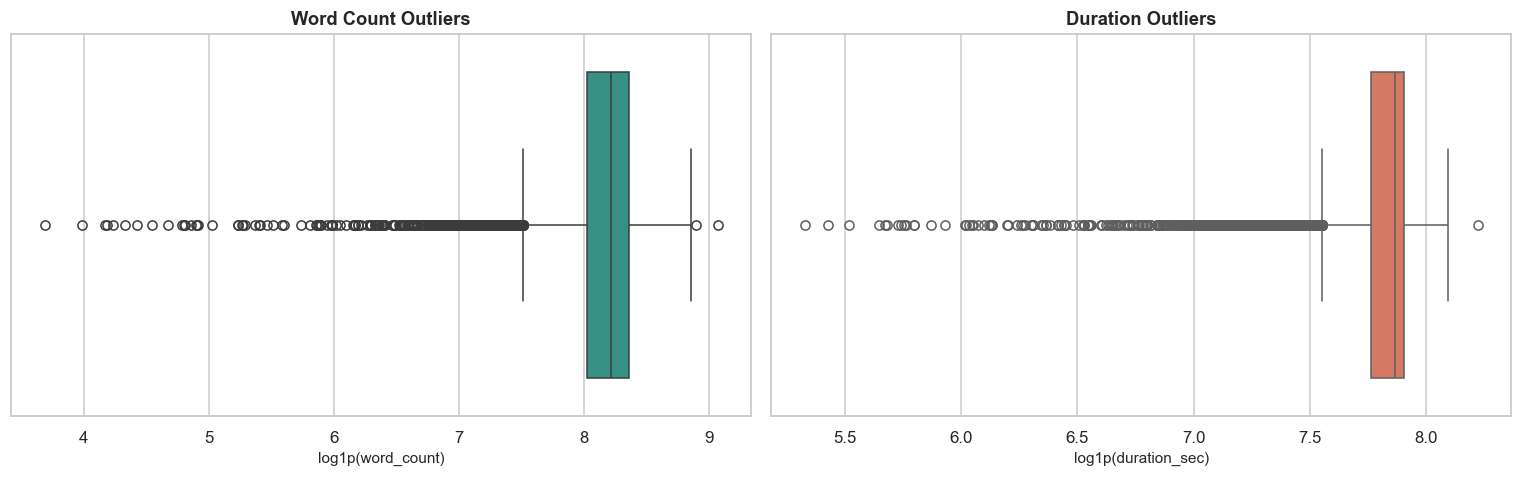


Outlier Insight: Long-session outliers are retained and flagged instead of clipped. They may be genuinely informative, but they can dominate linear scaling and Transformer token budgets; log transforms or robust scaling should be considered during model preprocessing.


In [14]:
def iqr_bounds(series: pd.Series, multiplier: float = 1.5) -> tuple[float, float]:
    q1, q3 = series.quantile([0.25, 0.75])
    spread = q3 - q1
    return float(q1 - multiplier * spread), float(q3 + multiplier * spread)


outlier_columns = [
    "word_count",
    "char_count",
    "duration_sec",
    "total_turns",
    "avg_words_per_turn",
]
outlier_rows = []
for column in outlier_columns:
    lower, upper = iqr_bounds(session_text_features[column])
    mask = (session_text_features[column] < lower) | (session_text_features[column] > upper)
    outlier_rows.append(
        {
            "feature": column,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_sessions": int(mask.sum()),
            "outlier_pct": mask.mean() * 100,
        }
    )

outlier_report = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outlier_report)

word_lower, word_upper = iqr_bounds(session_text_features["word_count"])
duration_lower, duration_upper = iqr_bounds(session_text_features["duration_sec"])
engineered_df["word_count_outlier"] = (
    (engineered_df["word_count"] < word_lower)
    | (engineered_df["word_count"] > word_upper)
).astype("int8")
engineered_df["duration_outlier"] = (
    (engineered_df["duration_sec"] < duration_lower)
    | (engineered_df["duration_sec"] > duration_upper)
).astype("int8")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(x=np.log1p(session_text_features["word_count"]), color="#2A9D8F", ax=axes[0])
axes[0].set(title="Word Count Outliers", xlabel="log1p(word_count)")
sns.boxplot(x=np.log1p(session_text_features["duration_sec"]), color="#E76F51", ax=axes[1])
axes[1].set(title="Duration Outliers", xlabel="log1p(duration_sec)")
plt.tight_layout()
plt.show()

print_insight(
    "Outlier Insight",
    "Long-session outliers are retained and flagged instead of clipped. They may be genuinely informative, "
    "but they can dominate linear scaling and Transformer token budgets; log transforms or robust scaling "
    "should be considered during model preprocessing.",
)

## 11. Numerical correlation and redundancy

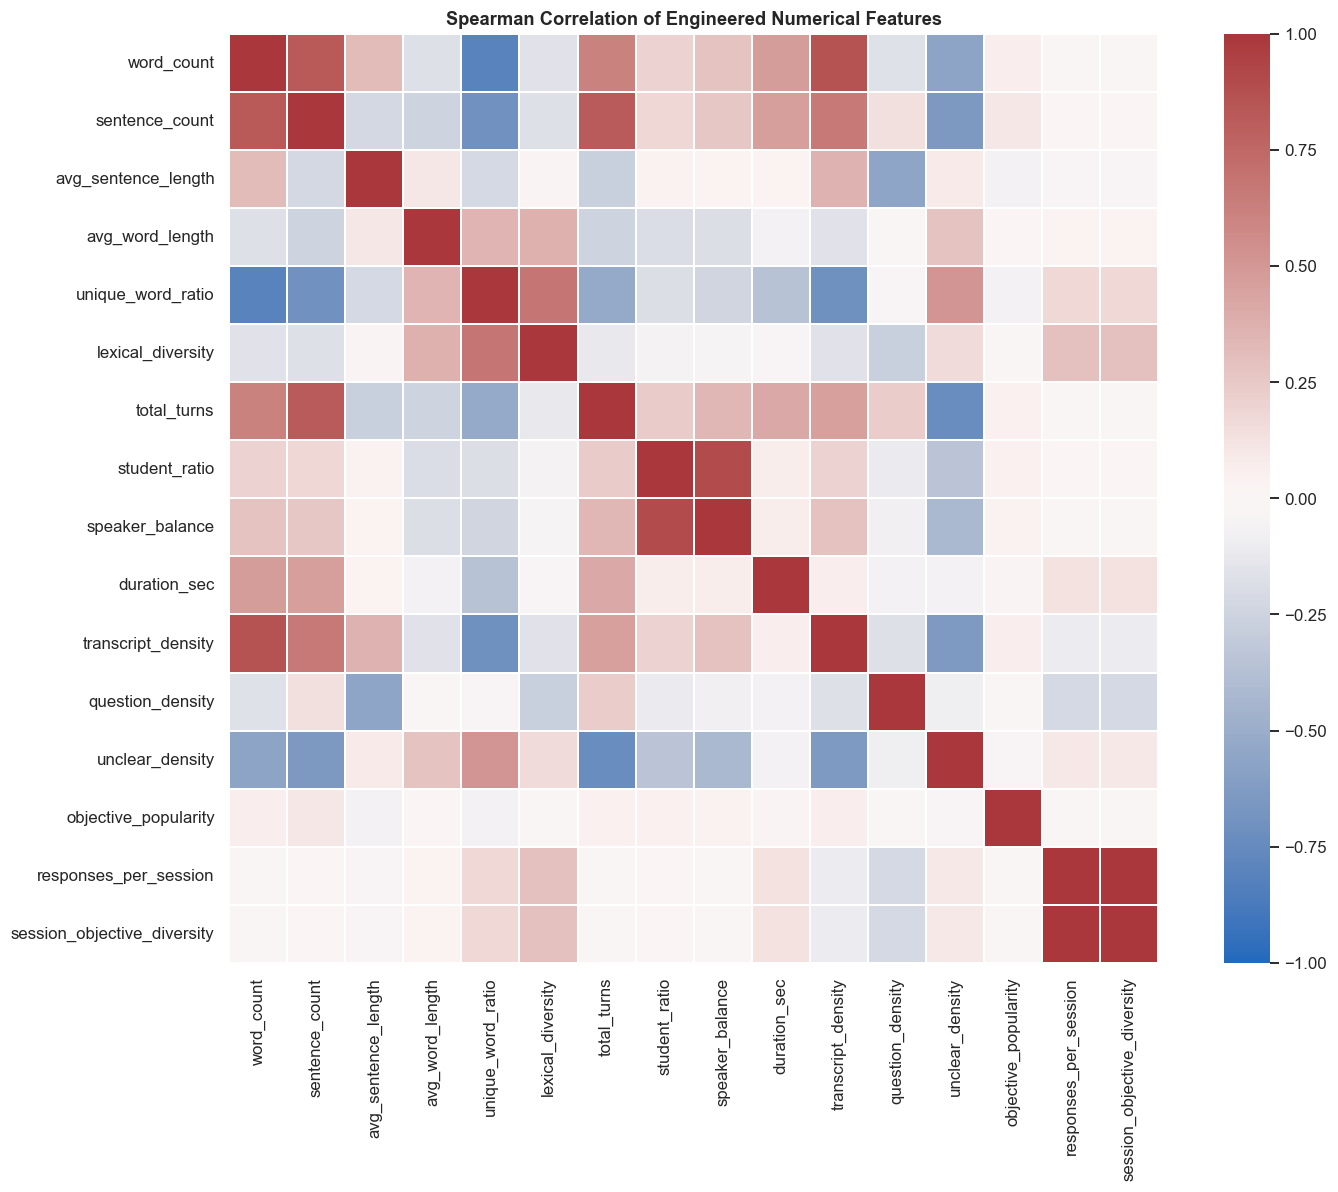

,,correlation
responses_per_session,session_objective_diversity,1.0000
student_ratio,speaker_balance,0.8932
word_count,transcript_density,0.8636



Correlation Insight: 3 feature pair(s) have absolute Spearman correlation at least 0.85. Tree models tolerate much of this redundancy, while linear models may benefit from pruning or regularization.


In [15]:
correlation_columns = [
    "word_count",
    "sentence_count",
    "avg_sentence_length",
    "avg_word_length",
    "unique_word_ratio",
    "lexical_diversity",
    "total_turns",
    "student_ratio",
    "speaker_balance",
    "duration_sec",
    "transcript_density",
    "question_density",
    "unclear_density",
    "objective_popularity",
    "responses_per_session",
    "session_objective_diversity",
]
corr = engineered_df[correlation_columns].corr(method="spearman")

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    ax=ax,
)
ax.set_title("Spearman Correlation of Engineered Numerical Features")
plt.tight_layout()
plt.show()

upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = (
    upper_triangle.stack()
    .rename("correlation")
    .loc[lambda values: values.abs() >= 0.85]
    .sort_values(key=np.abs, ascending=False)
)
display(strong_pairs.to_frame().head(15))
print_insight(
    "Correlation Insight",
    f"{len(strong_pairs)} feature pair(s) have absolute Spearman correlation at least 0.85. "
    "Tree models tolerate much of this redundancy, while linear models may benefit from pruning or regularization.",
)

### Feature Engineering Insight

Length, turn, timing, lexical, quality, objective, and session features capture different hypotheses:
how much evidence is present, who dominates the interaction, how noisy the transcript is, and how broad
the session is. Highly correlated raw counts are intentionally retained for flexible tree models, but
the correlation report identifies candidates for pruning in linear or distance-based models.

## 12. Leakage-safe feature importance preview

,spearman_with_target
session_objective_diversity,0.1476
responses_per_session,0.1476
session_average_response_length,-0.1174
question_density,-0.0838
unique_word_count,0.0775
lexical_diversity,0.0715
avg_word_length,0.0660
avg_words_per_turn,0.0517
question_count,-0.0496
avg_sentence_length,0.0465


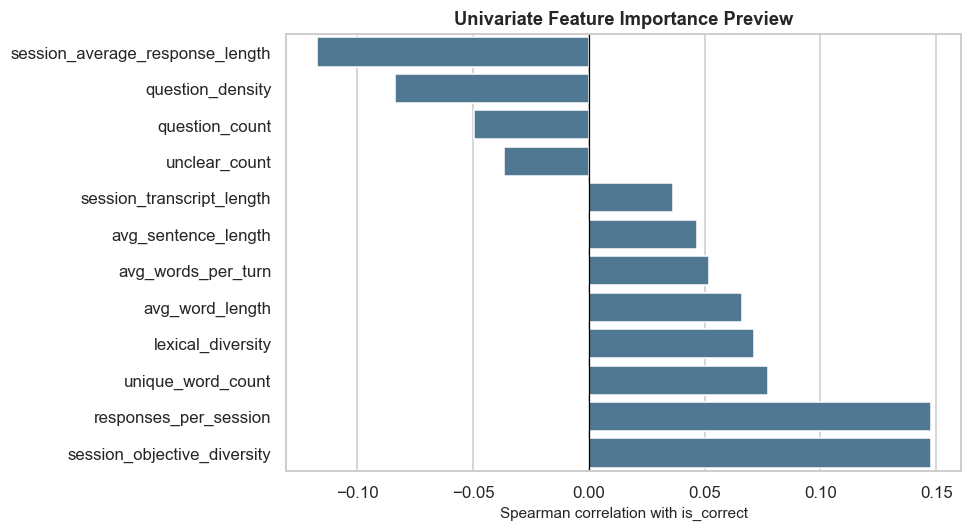


Feature Importance Preview: These are univariate associations, not validated model importances. They help prioritize checks, but final importance should come from group-aware cross-validation using permutation importance or SHAP.


In [16]:
candidate_numeric_features = [
    column
    for column in engineered_df.select_dtypes(include=[np.number, "boolean"]).columns
    if column != TARGET
]

# Diagnostic only: this uses the target to rank existing features, never to create a new feature.
target_association = (
    engineered_df[candidate_numeric_features]
    .corrwith(engineered_df[TARGET].astype(float), method="spearman")
    .dropna()
    .sort_values(key=np.abs, ascending=False)
    .rename("spearman_with_target")
)
display(target_association.head(15).to_frame())

fig, ax = plt.subplots(figsize=(9, 5))
preview = target_association.head(12).sort_values()
sns.barplot(x=preview.values, y=preview.index, color="#457B9D", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    title="Univariate Feature Importance Preview",
    xlabel="Spearman correlation with is_correct",
    ylabel="",
)
plt.tight_layout()
plt.show()

print_insight(
    "Feature Importance Preview",
    "These are univariate associations, not validated model importances. They help prioritize checks, "
    "but final importance should come from group-aware cross-validation using permutation importance or SHAP.",
)

## 13. Data leakage safeguards

Features deliberately avoided:

- Objective, session, tutor, or student correctness rates.
- Target means, target encodings, and historical accuracy computed on the full dataset.
- Any aggregate whose formula references `is_correct`.
- Random row-level validation that allows the same session transcript into train and validation.

Frequency features use only identifiers and row counts, so they do not directly leak the target.
However, for the cleanest competition validation, learn frequency mappings inside each training fold,
map validation rows from that fold, and reserve a fallback for unseen categories.

## 14. Model-ready column groups

In [17]:
identifier_columns = [
    "response_id",
    "session_id",
]
categorical_columns = [
    "learning_objective_id",
    "learning_objective",
]
text_columns = [
    "transcript",
    "clean_transcript",
]
target_column = TARGET
numerical_columns = [
    column
    for column in engineered_df.select_dtypes(include=[np.number, "boolean"]).columns
    if column != TARGET
]

model_column_groups = {
    "identifier_columns": identifier_columns,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "text_columns": text_columns,
    "target": [target_column],
}

for group_name, columns in model_column_groups.items():
    print(f"{group_name} ({len(columns)}):")
    print(columns)
    print()

print(
    "LightGBM/XGBoost: encode categoricals and use numerical features; add TF-IDF/SVD from clean_transcript.\n"
    "CatBoost: pass categorical columns directly and optionally configure clean_transcript as a text feature.\n"
    "Transformers: tokenize clean_transcript and concatenate standardized numerical/context features in a hybrid model."
)

identifier_columns (2):
['response_id', 'session_id']

categorical_columns (2):
['learning_objective_id', 'learning_objective']

numerical_columns (38):
['char_count', 'word_count', 'sentence_count', 'avg_sentence_length', 'avg_word_length', 'unique_word_count', 'unique_word_ratio', 'vocabulary_richness', 'lexical_diversity', 'punctuation_count', 'uppercase_count', 'digit_count', 'tutor_turns', 'student_turns', 'background_turns', 'total_turns', 'tutor_student_ratio', 'avg_words_per_turn', 'unclear_count', 'question_count', 'exclamation_count', 'response_density', 'duration_sec', 'student_ratio', 'tutor_ratio', 'speaker_balance', 'transcript_density', 'question_density', 'unclear_density', 'objective_frequency', 'objective_popularity', 'responses_per_objective', 'responses_per_session', 'session_transcript_length', 'session_average_response_length', 'session_objective_diversity', 'word_count_outlier', 'duration_outlier']

text_columns (2):
['transcript', 'clean_transcript']

target (1)

## 15. Feature catalog and artifact export

In [18]:
FEATURE_DESCRIPTIONS = {
    "response_id": "Unique response identifier.",
    "session_id": "Conversation/session identifier; use as the validation group.",
    "learning_objective_id": "Categorical identifier for the assessed learning objective.",
    "learning_objective": "Human-readable learning objective text.",
    "is_correct": "Binary prediction target.",
    "transcript": "Original timestamped, speaker-attributed session transcript.",
    "clean_transcript": "Normalized spoken text with timestamps, metadata, and unusual symbols removed.",
    "char_count": "Number of characters in spoken transcript content.",
    "word_count": "Number of word tokens in spoken transcript content.",
    "sentence_count": "Number of sentence-ending punctuation groups.",
    "avg_sentence_length": "Words per sentence.",
    "avg_word_length": "Average characters per word.",
    "unique_word_count": "Number of unique case-normalized words.",
    "unique_word_ratio": "Unique words divided by total words.",
    "vocabulary_richness": "Type-token ratio measuring vocabulary variety.",
    "lexical_diversity": "Guiraud-style unique words divided by square root of word count.",
    "punctuation_count": "Count of ASCII punctuation characters.",
    "uppercase_count": "Count of uppercase characters in spoken content.",
    "digit_count": "Count of digit characters in spoken content.",
    "tutor_turns": "Number of transcript turns labeled tutor.",
    "student_turns": "Number of transcript turns labeled student.",
    "background_turns": "Number of transcript turns labeled background.",
    "total_turns": "Total recognized speaker turns.",
    "tutor_student_ratio": "Tutor turns divided by student turns.",
    "avg_words_per_turn": "Transcript words divided by total turns.",
    "unclear_count": "Count of unclear transcription markers.",
    "question_count": "Count of question marks in spoken content.",
    "exclamation_count": "Count of exclamation marks in spoken content.",
    "response_density": "Student turns divided by all recognized turns.",
    "duration_sec": "Difference between maximum and minimum transcript timestamps in seconds.",
    "student_ratio": "Student turns divided by all recognized turns.",
    "tutor_ratio": "Tutor turns divided by all recognized turns.",
    "speaker_balance": "Balance of tutor and student turn counts; 1 is most balanced.",
    "transcript_density": "Words per timestamped second.",
    "question_density": "Question marks per word.",
    "unclear_density": "Unclear markers per recognized turn.",
    "objective_frequency": "Number of rows associated with the learning objective.",
    "objective_popularity": "Objective frequency divided by all response rows.",
    "responses_per_objective": "Unique response IDs associated with the objective.",
    "responses_per_session": "Number of scored responses in the session.",
    "session_transcript_length": "Character count of the selected session transcript.",
    "session_average_response_length": "Session word count divided by scored responses in the session.",
    "session_objective_diversity": "Number of unique learning objectives assessed in the session.",
    "word_count_outlier": "IQR flag for unusually short or long word count.",
    "duration_outlier": "IQR flag for unusually short or long timestamp duration.",
}


def expected_importance(feature_name: str) -> str:
    if feature_name in {"transcript", "clean_transcript", "learning_objective_id", "learning_objective"}:
        return "High"
    if feature_name in {
        "word_count",
        "duration_sec",
        "student_ratio",
        "speaker_balance",
        "objective_frequency",
        "objective_popularity",
        "responses_per_session",
        "session_objective_diversity",
        "unclear_density",
        "question_density",
    }:
        return "Medium-High"
    if feature_name in identifier_columns or feature_name == TARGET:
        return "Excluded / target"
    return "Medium"


feature_summary = pd.DataFrame(
    {
        "feature_name": engineered_df.columns,
        "dtype": [str(engineered_df[column].dtype) for column in engineered_df.columns],
        "description": [
            FEATURE_DESCRIPTIONS.get(column, "Engineered model feature.")
            for column in engineered_df.columns
        ],
        "importance_expectation": [
            expected_importance(column) for column in engineered_df.columns
        ],
    }
)
display(feature_summary)

OUTPUT_PARQUET = Path("train_engineered.parquet")
OUTPUT_CSV = Path("train_engineered.csv")
OUTPUT_SUMMARY = Path("feature_summary.csv")

engineered_df.to_parquet(OUTPUT_PARQUET, index=False, compression="zstd")
engineered_df.to_csv(OUTPUT_CSV, index=False)
feature_summary.to_csv(OUTPUT_SUMMARY, index=False)

print(f"Saved {OUTPUT_PARQUET.resolve()}")
print(f"Saved {OUTPUT_CSV.resolve()}")
print(f"Saved {OUTPUT_SUMMARY.resolve()}")

,feature_name,dtype,description,importance_expectation
0,response_id,string,Unique response identifier.,Excluded / target
1,session_id,string,Conversation/session identifier; use as the validation group.,Excluded / target
2,learning_objective_id,string,Categorical identifier for the assessed learning objective.,High
3,learning_objective,category,Human-readable learning objective text.,High
4,is_correct,Int8,Binary prediction target.,Excluded / target
5,transcript,string,"Original timestamped, speaker-attributed session transcript.",High
6,clean_transcript,string,"Normalized spoken text with timestamps, metadata, and unusual symbols removed.",High
7,char_count,int64,Number of characters in spoken transcript content.,Medium
8,word_count,int64,Number of word tokens in spoken transcript content.,Medium-High
9,sentence_count,int64,Number of sentence-ending punctuation groups.,Medium


Saved D:\Competition\Trace-The-Race-Competition\notebook\train_engineered.parquet
Saved D:\Competition\Trace-The-Race-Competition\notebook\train_engineered.csv
Saved D:\Competition\Trace-The-Race-Competition\notebook\feature_summary.csv


## 16. Final pipeline report

In [19]:
original_columns = set(EXPECTED_COLUMNS)
new_features = [column for column in engineered_df.columns if column not in original_columns]
engineered_shape = engineered_df.shape
memory_after_mb = memory_mb(engineered_df)

print("=" * 80)
print("FEATURE ENGINEERING PIPELINE COMPLETE")
print("=" * 80)
print(f"Original shape: {original_shape}")
print(f"Engineered shape: {engineered_shape}")
print(f"Number of new features: {len(new_features)}")
print(f"Memory usage before: {memory_before_mb:,.2f} MiB")
print(f"Memory usage after: {memory_after_mb:,.2f} MiB")
print("\nNewly created features:")
for feature_number, feature_name in enumerate(new_features, start=1):
    print(f"{feature_number:>2}. {feature_name}")

print_insight(
    "Final Insight",
    "The artifacts are ready for group-aware model training. Use session-grouped folds, fit aggregate "
    "mappings within folds for strict validation, and compare structured-only, text-only, and hybrid models.",
)

FEATURE ENGINEERING PIPELINE COMPLETE
Original shape: (35072, 6)
Engineered shape: (35072, 45)
Number of new features: 39
Memory usage before: 1,592.74 MiB
Memory usage after: 1,379.64 MiB

Newly created features:
 1. clean_transcript
 2. char_count
 3. word_count
 4. sentence_count
 5. avg_sentence_length
 6. avg_word_length
 7. unique_word_count
 8. unique_word_ratio
 9. vocabulary_richness
10. lexical_diversity
11. punctuation_count
12. uppercase_count
13. digit_count
14. tutor_turns
15. student_turns
16. background_turns
17. total_turns
18. tutor_student_ratio
19. avg_words_per_turn
20. unclear_count
21. question_count
22. exclamation_count
23. response_density
24. duration_sec
25. student_ratio
26. tutor_ratio
27. speaker_balance
28. transcript_density
29. question_density
30. unclear_density
31. objective_frequency
32. objective_popularity
33. responses_per_objective
34. responses_per_session
35. session_transcript_length
36. session_average_response_length
37. session_objective_


## 17. Competition-grade feature engineering v2

This section extends the completed baseline pipeline without rebuilding it. It is deliberately
target-blind: no feature below references `is_correct`. Frequency, TF-IDF, and embedding
vocabularies are unsupervised and are fit on the available training corpus for final artifact
creation. During model validation, fit those transformations on each training fold and transform
the held-out fold only.

The configured semantic model can be changed between `all-MiniLM-L6-v2` and
`BAAI/bge-small-en-v1.5`. The default is MiniLM because it is lightweight and commonly available
in Kaggle environments.


In [ ]:

# V2 configuration is intentionally centralized so Kaggle runs can tune cost versus signal.
import os
from collections import Counter
from functools import lru_cache
from pathlib import Path

from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import normalize as sparse_normalize

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

try:
    import shap
except ImportError:
    shap = None

try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    SentenceTransformer = None


V2_SEED = 42
TFIDF_WORD_MAX_FEATURES = int(os.getenv("TFIDF_WORD_MAX_FEATURES", "256"))
TFIDF_CHAR_MAX_FEATURES = int(os.getenv("TFIDF_CHAR_MAX_FEATURES", "128"))
TFIDF_WORD_NGRAM_RANGE = (1, 2)
TFIDF_CHAR_NGRAM_RANGE = (3, 5)
TFIDF_MIN_DF = int(os.getenv("TFIDF_MIN_DF", "3"))
TFIDF_MAX_CHARS = int(os.getenv("TFIDF_MAX_CHARS", "12000"))
EMBEDDING_MODEL_NAME = os.getenv("EMBEDDING_MODEL_NAME", "all-MiniLM-L6-v2")
EMBEDDING_BATCH_SIZE = int(os.getenv("EMBEDDING_BATCH_SIZE", "32"))
EMBEDDING_MAX_WORDS = int(os.getenv("EMBEDDING_MAX_WORDS", "220"))
RARE_WORD_MAX_CORPUS_COUNT = 2

SUPPORTED_EMBEDDING_MODELS = {
    "all-MiniLM-L6-v2": "sentence-transformers/all-MiniLM-L6-v2",
    "BAAI/bge-small-en-v1.5": "BAAI/bge-small-en-v1.5",
}
if EMBEDDING_MODEL_NAME not in SUPPORTED_EMBEDDING_MODELS:
    raise ValueError(
        f"Unsupported EMBEDDING_MODEL_NAME={EMBEDDING_MODEL_NAME!r}. "
        f"Choose one of {sorted(SUPPORTED_EMBEDDING_MODELS)}."
    )

# Use a copy so the original completed pipeline remains inspectable in the notebook.
base_v2 = engineered_df.copy()
original_engineered_columns = base_v2.columns.tolist()

# These are exact aliases or unstable duplicate names in the original feature set. The
# replacement names below preserve the information while making the v2 schema unambiguous.
EXACT_ALIAS_REPLACEMENTS = {
    "unique_word_ratio": "type_token_ratio",
    "vocabulary_richness": "vocabulary_richness",
    "avg_word_length": "avg_token_length",
    "response_density": "student_ratio",
    "responses_per_objective": "objective_frequency",
}
DROP_EXACT_ALIASES = [
    "unique_word_ratio",
    "vocabulary_richness",
    "avg_word_length",
    "response_density",
    "responses_per_objective",
]
base_v2 = base_v2.drop(columns=[c for c in DROP_EXACT_ALIASES if c in base_v2.columns])


def feature_family(feature_name: str) -> str:
    if feature_name.startswith("tfidf_word_"):
        return "tfidf_word_ngram"
    if feature_name.startswith("tfidf_char_"):
        return "tfidf_character_ngram"
    if feature_name.startswith("transcript_embedding_"):
        return "transcript_embedding"
    if feature_name.startswith("objective_embedding_"):
        return "objective_embedding"
    if feature_name in {"cosine_similarity", "semantic_distance", "objective_alignment_score"}:
        return "semantic_alignment"
    if feature_name.startswith("objective_"):
        return "learning_objective"
    if feature_name.startswith("session_") or feature_name in {
        "responses_per_session",
        "session_engagement",
        "session_average_duration",
    }:
        return "session_context"
    if feature_name.startswith("interaction_"):
        return "interaction"
    if feature_name.startswith(("tutor_", "student_", "conversation_", "backchannel", "turn_")):
        return "dialogue_behaviour"
    if feature_name.startswith(("flesch_", "gunning_", "smog_", "coleman_", "automated_")):
        return "readability"
    if feature_name in {
        "stopword_ratio",
        "rare_word_ratio",
        "repeated_word_ratio",
        "avg_token_length",
        "longest_sentence_words",
        "shortest_sentence_words",
        "sentence_length_variance",
        "type_token_ratio",
        "moving_ttr",
        "hapax_legomena_count",
        "hapax_legomena_ratio",
        "vocabulary_richness",
        "lexical_entropy",
    }:
        return "lexical_nlp"
    if feature_name.endswith("_ratio") or feature_name in {
        "timestamp_count",
        "unclear_count",
        "digit_count",
        "uppercase_count",
        "punctuation_count",
    }:
        return "transcript_quality"
    if feature_name in {"transcript", "clean_transcript"}:
        return "text"
    if feature_name in {"response_id", "session_id", "learning_objective_id"}:
        return "identifier"
    if feature_name == TARGET:
        return "target"
    return "structured_baseline"


existing_recommendations = {
    "response_id": ("Remove", "Identifier only; never pass to a model."),
    "session_id": ("Remove", "Validation group and join key; retaining it as a predictor leaks session identity."),
    "learning_objective_id": (
        "Useful",
        "Strong categorical context, but encode inside each fold and do not use as a raw ordinal number.",
    ),
    "learning_objective": ("Highly Recommended", "Objective text provides curriculum semantics."),
    TARGET: ("Remove", "Target column, retained only as the supervised label."),
    "transcript": ("Highly Recommended", "Retain for text models and auditability."),
    "clean_transcript": ("Highly Recommended", "Normalized text is the stable input for sparse and semantic models."),
    "word_count": ("Useful", "Robust amount-of-evidence signal; log-transform for linear models."),
    "char_count": ("Useful", "Length signal, but correlated with word and sentence counts."),
    "sentence_count": ("Useful", "Captures response structure and completeness."),
    "avg_sentence_length": ("Useful", "Captures syntactic density."),
    "avg_word_length": ("Remove", "Exact alias of the v2 `avg_token_length`."),
    "unique_word_ratio": ("Remove", "Exact alias of the v2 `type_token_ratio`."),
    "vocabulary_richness": ("Remove", "Original definition duplicated `unique_word_ratio`; v2 uses a distinct log-richness metric."),
    "lexical_diversity": ("Useful", "Guiraud-style diversity is less length-biased than raw type-token ratio."),
    "punctuation_count": ("Useful", "Conversation and transcription quality signal."),
    "uppercase_count": ("Weak", "Usually dominated by sentence starts and speaker metadata."),
    "digit_count": ("Useful", "Math/numeric content and transcription signal."),
    "tutor_turns": ("Useful", "Tutor scaffolding and session structure."),
    "student_turns": ("Highly Recommended", "Student participation is a direct engagement proxy."),
    "background_turns": ("Weak", "Often represents audio metadata or diarization noise."),
    "total_turns": ("Useful", "Strong interaction-length signal, correlated with speaker turn counts."),
    "tutor_student_ratio": ("Weak", "Unstable at zero student turns; prefer bounded ratios and balance."),
    "avg_words_per_turn": ("Useful", "Turn-level verbosity and interaction structure."),
    "unclear_count": ("Useful", "Audio/transcription quality signal."),
    "question_count": ("Useful", "Tutor questioning and student uncertainty context."),
    "exclamation_count": ("Weak", "Sparse stylistic marker; retain only as a low-priority feature."),
    "response_density": ("Remove", "Exact alias of `student_ratio`."),
    "duration_sec": ("Highly Recommended", "Session pacing and available interaction time."),
    "student_ratio": ("Highly Recommended", "Bounded participation signal."),
    "tutor_ratio": ("Useful", "Tutor/student allocation signal."),
    "speaker_balance": ("Highly Recommended", "Bounded measure of bidirectional interaction."),
    "transcript_density": ("Useful", "Speech volume per second."),
    "question_density": ("Useful", "Normalizes questioning by transcript length."),
    "unclear_density": ("Useful", "Normalizes transcription issues by turn count."),
    "objective_frequency": ("Highly Recommended", "Target-independent curriculum support count."),
    "objective_popularity": ("Useful", "Normalized version of objective frequency."),
    "responses_per_objective": ("Remove", "Exact alias of `objective_frequency` because response IDs are unique."),
    "responses_per_session": ("Highly Recommended", "Session workload and repeated-evaluation context."),
    "session_transcript_length": ("Weak", "Original version duplicated `char_count`; v2 overwrites it with raw session length."),
    "session_average_response_length": ("Useful", "Session context, but correlated with transcript length."),
    "session_objective_diversity": ("Useful", "Session scope and curricular breadth."),
    "word_count_outlier": ("Weak", "Useful for robust models, but threshold depends on the training corpus."),
    "duration_outlier": ("Weak", "Useful as a robust flag, but threshold depends on the training corpus."),
}

existing_audit_rows = []
for column in original_engineered_columns:
    recommendation, reason = existing_recommendations.get(
        column, ("Useful", "Retained baseline feature; validate with grouped CV.")
    )
    existing_audit_rows.append(
        {
            "feature_name": column,
            "family": feature_family(column),
            "recommendation": recommendation,
            "reason": reason,
            "dtype": str(engineered_df[column].dtype),
            "missing_pct": float(engineered_df[column].isna().mean() * 100),
            "nunique": int(engineered_df[column].nunique(dropna=False)),
        }
    )
existing_feature_audit = pd.DataFrame(existing_audit_rows)
display(existing_feature_audit)


@lru_cache(maxsize=200000)
def estimate_syllables(word: str) -> int:
    word = re.sub(r"[^a-z]", "", word.lower())
    if not word:
        return 0
    if len(word) <= 3:
        return 1
    groups = len(re.findall(r"[aeiouy]+", word))
    if word.endswith("e") and not word.endswith(("le", "ye")) and groups > 1:
        groups -= 1
    if word.endswith("es") and len(word) > 4 and groups > 1:
        groups -= 1
    return max(groups, 1)


def _phrase_count(text: str, pattern: re.Pattern[str]) -> int:
    return len(pattern.findall(text))


PRAISE_RE = re.compile(
    r"\b(?:good job|well done|great|excellent|brilliant|awesome|nice work|that's right|perfect|fantastic)\b",
    re.I,
)
CORRECTION_RE = re.compile(
    r"\b(?:not quite|almost|try again|incorrect|that's not|you need to|remember|check your|mistake|rather)\b",
    re.I,
)
ACK_RE = re.compile(r"\b(?:okay|ok|yes|yeah|yep|yup|alright|all right|got it|i see)\b", re.I)
UNCERTAINTY_RE = re.compile(
    r"\b(?:not sure|i don't know|i dont know|unsure|maybe|i think|i'm not sure|perhaps)\b",
    re.I,
)
CONFIDENCE_RE = re.compile(
    r"\b(?:yes|yeah|correct|right|i know|i can|definitely|sure|certain)\b", re.I
)
BACKCHANNEL_RE = re.compile(r"\b(?:uh huh|mm-hm|mm hmm|mhm|hmm|right|okay|yeah)\b", re.I)


def moving_ttr(tokens: list[str], window: int = 100) -> float:
    if not tokens:
        return 0.0
    if len(tokens) <= window:
        return len(set(tokens)) / len(tokens)
    step = max(window // 2, 1)
    values = []
    for start in range(0, len(tokens) - window + 1, step):
        chunk = tokens[start : start + window]
        values.append(len(set(chunk)) / window)
    return float(np.mean(values)) if values else len(set(tokens)) / len(tokens)


def analyze_advanced_transcript(raw_text: Any) -> dict[str, Any]:
    raw = "" if pd.isna(raw_text) else str(raw_text)
    normalized_raw = unicodedata.normalize("NFKC", raw)
    speaker_counts = {"tutor": 0, "student": 0, "background": 0}
    speaker_text = {"tutor": [], "student": [], "background": []}
    sequence = []
    utterances = []
    timestamp_count = len(TIMESTAMP_RE.findall(normalized_raw))

    for line in normalized_raw.splitlines():
        match = TURN_LINE_RE.match(line)
        if match:
            speaker = match.group(1).lower()
            text = match.group(2).strip()
            speaker_counts[speaker] += 1
            speaker_text[speaker].append(text)
            sequence.append(speaker)
            utterances.append(text)

    if not utterances:
        fallback = TIMESTAMP_RE.sub(" ", normalized_raw)
        fallback = SPEAKER_PREFIX_RE.sub(" ", fallback)
        utterances = [fallback]

    content = " ".join(utterances)
    tokens = [token.lower() for token in WORD_RE.findall(content)]
    token_count = len(tokens)
    token_counter = Counter(tokens)
    unique_count = len(token_counter)
    sentences = [
        sentence
        for sentence in re.split(r"(?<=[.!?])\s+", content.strip())
        if WORD_RE.search(sentence)
    ]
    sentence_lengths = np.array(
        [len(WORD_RE.findall(sentence)) for sentence in sentences], dtype=np.float32
    )
    if token_count and len(sentence_lengths) == 0:
        sentence_lengths = np.array([token_count], dtype=np.float32)

    alpha_count = sum(char.isalpha() for char in normalized_raw)
    raw_chars = max(len(normalized_raw), 1)
    punctuation = sum(char in string.punctuation for char in normalized_raw)
    digits = sum(char.isdigit() for char in normalized_raw)
    uppercase = sum(char.isupper() for char in normalized_raw)
    special = sum(
        not char.isalnum() and not char.isspace() and char not in string.punctuation
        for char in normalized_raw
    )
    whitespace = sum(char.isspace() for char in normalized_raw)
    total_syllables = sum(estimate_syllables(token) for token in tokens)
    complex_words = sum(estimate_syllables(token) >= 3 for token in tokens)
    sentence_count = max(len(sentence_lengths), 1) if token_count else 0
    words_per_sentence = token_count / max(sentence_count, 1)
    syllables_per_sentence = total_syllables / max(sentence_count, 1)

    tutor_text = " ".join(speaker_text["tutor"])
    student_text = " ".join(speaker_text["student"])
    tutor_turns = speaker_counts["tutor"]
    student_turns = speaker_counts["student"]
    total_turns = sum(speaker_counts.values())
    tutor_words = len(WORD_RE.findall(tutor_text))
    student_words = len(WORD_RE.findall(student_text))
    speaker_words = max(tutor_words + student_words, 1)
    alternation_pairs = [
        (left, right)
        for left, right in zip(sequence, sequence[1:])
        if left in {"tutor", "student"} and right in {"tutor", "student"}
    ]
    alternation_score = (
        sum(left != right for left, right in alternation_pairs) / len(alternation_pairs)
        if alternation_pairs
        else 0.0
    )
    conversation_balance = 1.0 - abs(tutor_words - student_words) / speaker_words
    student_share = student_words / speaker_words
    tutor_questions = _phrase_count(tutor_text, re.compile(r"\?", re.I))
    ack_count = _phrase_count(student_text, ACK_RE)
    backchannel_count = _phrase_count(student_text, BACKCHANNEL_RE)
    uncertainty_count = _phrase_count(student_text, UNCERTAINTY_RE)
    confidence_count = _phrase_count(student_text, CONFIDENCE_RE)
    engagement_score = float(
        np.clip(
            0.35 * student_share
            + 0.25 * min(student_turns / max(tutor_turns, 1), 1.0)
            + 0.20 * min(tutor_questions / max(student_turns, 1), 1.0)
            + 0.10 * min((ack_count + backchannel_count) / max(student_turns, 1), 1.0)
            + 0.10 * min(uncertainty_count + confidence_count, 3) / 3.0,
            0.0,
            1.0,
        )
    )
    lexical_entropy = (
        float(-sum((count / token_count) * np.log2(count / token_count) for count in token_counter.values()))
        if token_count
        else 0.0
    )
    type_token_ratio = unique_count / max(token_count, 1)
    vocabulary_richness = (
        np.log1p(unique_count) / np.log1p(token_count) if token_count > 1 else float(type_token_ratio)
    )

    return {
        "avg_token_length": safe_divide(sum(map(len, tokens)), token_count),
        "longest_sentence_words": float(sentence_lengths.max()) if len(sentence_lengths) else 0.0,
        "shortest_sentence_words": float(sentence_lengths.min()) if len(sentence_lengths) else 0.0,
        "sentence_length_variance": float(sentence_lengths.var()) if len(sentence_lengths) else 0.0,
        "stopword_ratio": safe_divide(sum(token in ENGLISH_STOP_WORDS for token in tokens), token_count),
        "repeated_word_ratio": safe_divide(sum(max(count - 1, 0) for count in token_counter.values()), token_count),
        "type_token_ratio": type_token_ratio,
        "moving_ttr": moving_ttr(tokens),
        "hapax_legomena_count": int(sum(count == 1 for count in token_counter.values())),
        "hapax_legomena_ratio": safe_divide(sum(count == 1 for count in token_counter.values()), unique_count),
        "vocabulary_richness": float(vocabulary_richness),
        "lexical_entropy": lexical_entropy,
        "timestamp_count": int(timestamp_count),
        "unclear_ratio": safe_divide(len(UNCLEAR_RE.findall(normalized_raw)), timestamp_count),
        "digit_ratio": digits / raw_chars,
        "capital_ratio": uppercase / max(alpha_count, 1),
        "punctuation_ratio": punctuation / raw_chars,
        "special_character_ratio": special / raw_chars,
        "whitespace_ratio": whitespace / raw_chars,
        "tutor_praise_count": _phrase_count(tutor_text, PRAISE_RE),
        "tutor_correction_count": _phrase_count(tutor_text, CORRECTION_RE),
        "tutor_question_count": tutor_questions,
        "student_acknowledgement_count": ack_count,
        "student_uncertainty_count": uncertainty_count,
        "student_confidence_count": confidence_count,
        "backchannel_count": backchannel_count,
        "conversation_balance": float(np.clip(conversation_balance, 0.0, 1.0)),
        "conversation_engagement_score": engagement_score,
        "turn_alternation_score": float(alternation_score),
        "flesch_reading_ease": float(
            206.835 - 1.015 * words_per_sentence - 84.6 * total_syllables / max(token_count, 1)
        ),
        "gunning_fog": float(
            0.4 * (words_per_sentence + 100 * complex_words / max(token_count, 1))
        ),
        "smog_index": float(
            1.043 * np.sqrt(complex_words * (30.0 / max(sentence_count, 1))) + 3.1291
            if complex_words
            else 0.0
        ),
        "coleman_liau_index": float(
            0.0588 * (100 * alpha_count / max(token_count, 1))
            - 0.296 * (100 * sentence_count / max(token_count, 1))
            - 15.8
        ),
        "automated_readability_index": float(
            4.71 * alpha_count / max(token_count, 1)
            + 0.5 * token_count / max(sentence_count, 1)
            - 21.43
        ),
    }


session_source = (
    base_v2[["session_id", "transcript", "clean_transcript"]]
    .assign(_raw_char_len=lambda x: x["transcript"].str.len())
    .sort_values("_raw_char_len", ascending=False)
    .drop_duplicates("session_id", keep="first")
    .drop(columns="_raw_char_len")
    .reset_index(drop=True)
)

advanced_records = []
for row_number, row in enumerate(session_source.itertuples(index=False), start=1):
    record = analyze_advanced_transcript(row.transcript)
    record["session_id"] = row.session_id
    advanced_records.append(record)
    if row_number % 2500 == 0 or row_number == len(session_source):
        print(f"Advanced transcript parsing: {row_number:,}/{len(session_source):,}")
advanced_session = pd.DataFrame.from_records(advanced_records)

# Corpus rarity is unsupervised. It is computed from transcript text only, never labels.
corpus_counts = Counter()
for text in session_source["clean_transcript"].fillna("").astype(str):
    corpus_counts.update(WORD_RE.findall(text.lower()))
rare_ratios = []
for text in session_source["clean_transcript"].fillna("").astype(str):
    tokens = [token.lower() for token in WORD_RE.findall(text)]
    rare_ratios.append(
        safe_divide(sum(corpus_counts[token] <= RARE_WORD_MAX_CORPUS_COUNT for token in tokens), len(tokens))
    )
advanced_session["rare_word_ratio"] = np.asarray(rare_ratios, dtype=np.float32)
advanced_session["session_id"] = advanced_session["session_id"].astype("string[pyarrow]")

# Objective text and frequency features are target-independent. No correctness statistic is
# computed here; target means/rates must be learned inside each training fold if ever needed.
objective_base = base_v2[
    ["learning_objective_id", "learning_objective"]
].drop_duplicates("learning_objective_id")
objective_counts = base_v2.groupby("learning_objective_id", observed=True)["response_id"].size()
objective_features = objective_base.copy()
objective_features["objective_rarity"] = objective_features["learning_objective_id"].map(
    lambda key: 1.0 / np.sqrt(float(objective_counts.get(key, 1)))
).astype("float32")
objective_features["objective_self_information"] = objective_features["learning_objective_id"].map(
    lambda key: -np.log2(float(objective_counts.get(key, 1)) / len(base_v2))
).astype("float32")
objective_features["objective_entropy"] = objective_features["learning_objective_id"].map(
    lambda key: -(
        float(objective_counts.get(key, 1)) / len(base_v2)
    ) * np.log2(float(objective_counts.get(key, 1)) / len(base_v2))
).astype("float32")
objective_features["objective_text_word_count"] = objective_features["learning_objective"].map(
    lambda value: len(WORD_RE.findall(str(value)))
).astype("int16")
objective_features["objective_text_char_count"] = objective_features["learning_objective"].str.len().astype("int16")
objective_features["objective_text_type_token_ratio"] = objective_features["learning_objective"].map(
    lambda value: safe_divide(
        len(set(WORD_RE.findall(str(value).lower()))),
        len(WORD_RE.findall(str(value))),
    )
).astype("float32")
objective_features = objective_features.drop(columns=["learning_objective"])


def bounded_semantic_text(text: str, max_words: int = EMBEDDING_MAX_WORDS) -> str:
    words = str(text).split()
    if len(words) <= max_words:
        return str(text)
    third = max(max_words // 3, 1)
    middle_start = max((len(words) - third) // 2, third)
    return " ".join(words[:third] + words[middle_start : middle_start + third] + words[-third:])


def add_tfidf_features(
    texts: pd.Series,
    word_max_features: int = TFIDF_WORD_MAX_FEATURES,
    char_max_features: int = TFIDF_CHAR_MAX_FEATURES,
) -> tuple[pd.DataFrame, dict[str, str]]:
    bounded_texts = texts.fillna("").astype(str).str.slice(0, TFIDF_MAX_CHARS)
    metadata = {}
    blocks = []
    for prefix, analyzer, ngram_range, max_features in [
        ("tfidf_word", "word", TFIDF_WORD_NGRAM_RANGE, word_max_features),
        ("tfidf_char", "char", TFIDF_CHAR_NGRAM_RANGE, char_max_features),
    ]:
        vectorizer = TfidfVectorizer(
            analyzer=analyzer,
            ngram_range=ngram_range,
            min_df=TFIDF_MIN_DF,
            max_df=0.995,
            max_features=max_features,
            sublinear_tf=True,
            strip_accents="unicode",
            dtype=np.float32,
        )
        matrix = vectorizer.fit_transform(bounded_texts.tolist())
        matrix = sparse_normalize(matrix, norm="l2", axis=1, copy=False)
        dense = matrix.toarray().astype(np.float32, copy=False)
        columns = []
        for index, term in enumerate(vectorizer.get_feature_names_out()):
            safe_term = re.sub(r"[^a-zA-Z0-9]+", "_", str(term)).strip("_")[:60] or "token"
            column = f"{prefix}_{index:04d}"
            columns.append(column)
            metadata[column] = f"TF-IDF {analyzer} n-gram ({ngram_range}) term={safe_term}"
        blocks.append(pd.DataFrame(dense, columns=columns))
        summary_prefix = "word" if analyzer == "word" else "char"
        blocks.append(
            pd.DataFrame(
                {
                    f"tfidf_{summary_prefix}_nnz": np.asarray(matrix.getnnz(axis=1)).ravel(),
                    f"tfidf_{summary_prefix}_mean": dense.mean(axis=1),
                    f"tfidf_{summary_prefix}_max": dense.max(axis=1) if dense.shape[1] else 0.0,
                }
            )
        )
        metadata[f"tfidf_{summary_prefix}_nnz"] = "Number of non-zero TF-IDF features."
        metadata[f"tfidf_{summary_prefix}_mean"] = "Mean normalized TF-IDF weight."
        metadata[f"tfidf_{summary_prefix}_max"] = "Maximum normalized TF-IDF weight."
    return pd.concat(blocks, axis=1), metadata


tfidf_session, tfidf_metadata = add_tfidf_features(session_source["clean_transcript"])
tfidf_session.insert(0, "session_id", session_source["session_id"].to_numpy())
tfidf_session["session_id"] = tfidf_session["session_id"].astype("string[pyarrow]")
print(f"TF-IDF session matrix: {tfidf_session.shape}; word max={TFIDF_WORD_MAX_FEATURES}, char max={TFIDF_CHAR_MAX_FEATURES}")


def encode_semantic_features(
    session_texts: pd.Series,
    objective_texts: pd.Series,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, str]]:
    if SentenceTransformer is None:
        raise ImportError(
            "Sentence Transformers is required for v2 embeddings. "
            "Install sentence-transformers or disable the semantic section explicitly."
        )
    model_id = SUPPORTED_EMBEDDING_MODELS[EMBEDDING_MODEL_NAME]
    print(f"Loading Sentence Transformer: {model_id}")
    model = SentenceTransformer(model_id, device="cpu")
    transcript_text = [
        bounded_semantic_text(text)
        for text in session_texts.astype("string").fillna("").astype(str)
    ]
    objective_text = objective_texts.astype("string").fillna("").astype(str).tolist()
    transcript_embeddings = model.encode(
        transcript_text,
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)
    objective_embeddings = model.encode(
        objective_text,
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)
    transcript_columns = [
        f"transcript_embedding_{index:03d}" for index in range(transcript_embeddings.shape[1])
    ]
    objective_columns = [
        f"objective_embedding_{index:03d}" for index in range(objective_embeddings.shape[1])
    ]
    transcript_frame = pd.DataFrame(transcript_embeddings, columns=transcript_columns)
    objective_frame = pd.DataFrame(objective_embeddings, columns=objective_columns)
    metadata = {
        column: f"Sentence Transformer {EMBEDDING_MODEL_NAME} transcript embedding dimension {index}"
        for index, column in enumerate(transcript_columns)
    }
    metadata.update(
        {
            column: f"Sentence Transformer {EMBEDDING_MODEL_NAME} learning-objective embedding dimension {index}"
            for index, column in enumerate(objective_columns)
        }
    )
    return transcript_frame, objective_frame, metadata


transcript_embeddings, objective_embeddings, embedding_metadata = encode_semantic_features(
    session_source["clean_transcript"],
    objective_base["learning_objective"],
)
transcript_embeddings.insert(0, "session_id", session_source["session_id"].to_numpy())
objective_embeddings.insert(0, "learning_objective_id", objective_base["learning_objective_id"].to_numpy())
transcript_embeddings["session_id"] = transcript_embeddings["session_id"].astype("string[pyarrow]")
objective_embeddings["learning_objective_id"] = objective_embeddings["learning_objective_id"].astype("string[pyarrow]")

v2 = base_v2.drop(
    columns=[
        column
        for column in [
            "session_transcript_length",
            "objective_rarity",
            "objective_self_information",
            "objective_entropy",
            "objective_text_word_count",
            "objective_text_char_count",
            "objective_text_type_token_ratio",
        ]
        if column in base_v2.columns
    ]
)
v2 = v2.merge(
    advanced_session,
    on="session_id",
    how="left",
    validate="many_to_one",
)
v2 = v2.merge(
    objective_features,
    on="learning_objective_id",
    how="left",
    validate="many_to_one",
)

session_lookup = advanced_session.set_index("session_id")
session_group = base_v2.groupby("session_id", observed=True)
session_objective_counts = (
    base_v2.groupby(["session_id", "learning_objective_id"], observed=True)
    .size()
    .rename("count")
)


def session_entropy(values: pd.Series) -> float:
    probabilities = values.to_numpy(dtype=float)
    probabilities = probabilities / probabilities.sum()
    return float(-np.sum(probabilities * np.log2(probabilities)))


session_context = pd.DataFrame({"session_id": session_group.size().index})
session_context["responses_per_session"] = session_context["session_id"].map(session_group.size()).astype("int16")
session_context["session_transcript_length"] = session_context["session_id"].map(
    base_v2.groupby("session_id", observed=True)["transcript"].first().str.len()
).astype("int32")
session_context["session_average_transcript_length"] = session_context["session_id"].map(
    base_v2.assign(_length=base_v2["transcript"].str.len())
    .groupby("session_id", observed=True)["_length"]
    .mean()
).astype("float32")
session_context["session_average_duration"] = session_context["session_id"].map(
    session_lookup["duration_sec"]
).astype("float32")
session_context["session_engagement"] = session_context["session_id"].map(
    session_lookup["conversation_engagement_score"]
).astype("float32")
session_context["session_unique_transcript_count"] = session_context["session_id"].map(
    base_v2.groupby("session_id", observed=True)["transcript"].nunique()
).astype("int16")
session_context["session_objective_entropy"] = session_context["session_id"].map(
    session_objective_counts.groupby(level=0).apply(session_entropy)
).astype("float32")

v2 = v2.drop(
    columns=[
        column
        for column in [
            "responses_per_session",
            "session_transcript_length",
            "session_average_response_length",
        ]
        if column in v2.columns
    ],
    errors="ignore",
)
v2 = v2.merge(session_context, on="session_id", how="left", validate="many_to_one")
v2 = v2.merge(tfidf_session, on="session_id", how="left", validate="many_to_one")
v2 = v2.merge(
    transcript_embeddings,
    on="session_id",
    how="left",
    validate="many_to_one",
)
v2 = v2.merge(
    objective_embeddings,
    on="learning_objective_id",
    how="left",
    validate="many_to_one",
)

transcript_embedding_columns = [
    column for column in v2.columns if column.startswith("transcript_embedding_")
]
objective_embedding_columns = [
    column for column in v2.columns if column.startswith("objective_embedding_")
]
transcript_matrix = v2[transcript_embedding_columns].to_numpy(dtype=np.float32)
objective_matrix = v2[objective_embedding_columns].to_numpy(dtype=np.float32)
v2["cosine_similarity"] = np.clip(
    np.einsum("ij,ij->i", transcript_matrix, objective_matrix),
    -1.0,
    1.0,
).astype("float32")
v2["semantic_distance"] = (1.0 - v2["cosine_similarity"]).astype("float32")


def objective_keyword_coverage(transcript: Any, objective: Any) -> float:
    transcript_words = set(WORD_RE.findall(str(transcript).lower()))
    objective_words = {
        token
        for token in WORD_RE.findall(str(objective).lower())
        if token not in ENGLISH_STOP_WORDS
    }
    return safe_divide(len(transcript_words & objective_words), len(objective_words))


v2["objective_keyword_coverage"] = [
    objective_keyword_coverage(transcript, objective)
    for transcript, objective in zip(v2["clean_transcript"], v2["learning_objective"])
]
v2["objective_alignment_score"] = (
    0.70 * ((v2["cosine_similarity"] + 1.0) / 2.0)
    + 0.30 * v2["objective_keyword_coverage"]
).astype("float32")

# Target-independent interactions requested for tree and linear downstream models.
v2["interaction_word_count_x_objective_frequency"] = (
    v2["word_count"].astype("float32") * v2["objective_frequency"].astype("float32")
)
v2["interaction_duration_x_tutor_turns"] = (
    v2["duration_sec"].astype("float32") * v2["tutor_turns"].astype("float32")
)
v2["interaction_student_ratio_x_transcript_length"] = (
    v2["student_ratio"].astype("float32") * v2["char_count"].astype("float32")
)
v2["interaction_question_density_x_duration"] = (
    v2["question_density"].astype("float32") * v2["duration_sec"].astype("float32")
)

# Add the new session-level quality and objective features that were computed above.
v2["session_transcript_length"] = v2["session_transcript_length"].astype("int32")


def downcast_v2_dtypes(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    for column in result.select_dtypes(include=["float64"]).columns:
        result[column] = pd.to_numeric(result[column], downcast="float")
    for column in result.select_dtypes(include=["int64"]).columns:
        result[column] = pd.to_numeric(result[column], downcast="integer")
    for column in result.select_dtypes(include=["object"]).columns:
        if column in {"learning_objective"} or result[column].nunique(dropna=False) < max(100, len(result) // 100):
            result[column] = result[column].astype("category")
    if TARGET in result.columns:
        result[TARGET] = result[TARGET].astype("Int8")
    return result


v2 = downcast_v2_dtypes(v2)
assert TARGET in v2.columns
assert not any(
    column.startswith(("target_", "label_", "correctness_", "oof_"))
    for column in v2.columns
)
assert len(v2) == len(base_v2) == len(df)
print(f"V2 engineered shape before redundancy audit: {v2.shape}")


# Structured-only multicollinearity and model diagnostics. IDs, raw text, sparse text, and
# embeddings are excluded so this preview answers the requested structured-feature question.
NON_STRUCTURED_PREFIXES = (
    "tfidf_",
    "transcript_embedding_",
    "objective_embedding_",
)
structured_columns = [
    column
    for column in v2.select_dtypes(include=[np.number, "boolean"]).columns
    if column != TARGET and not column.startswith(NON_STRUCTURED_PREFIXES)
]
structured_columns = [
    column for column in structured_columns if v2[column].nunique(dropna=False) > 1
]
structured_matrix = (
    v2[structured_columns]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
    .astype("float32")
)

feature_corr_v2 = structured_matrix.corr(method="spearman").fillna(0.0)
feature_corr_v2.to_csv("feature_correlation.csv")

vif_rows = []
if structured_columns:
    corr_array = feature_corr_v2.to_numpy(dtype=np.float64)
    inverse_corr = np.linalg.pinv(corr_array, rcond=1e-10)
    vif_values = np.clip(np.diag(inverse_corr), 1.0, 1e9)
    vif_rows = [
        {"feature_name": column, "vif": float(vif)}
        for column, vif in zip(structured_columns, vif_values)
    ]
vif_table = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
vif_lookup = dict(zip(vif_table["feature_name"], vif_table["vif"]))
upper_corr = feature_corr_v2.where(
    np.triu(np.ones(feature_corr_v2.shape), k=1).astype(bool)
)
strong_pairs_v2 = (
    upper_corr.stack()
    .rename("spearman_correlation")
    .loc[lambda values: values.abs() >= 0.90]
    .sort_values(key=np.abs, ascending=False)
)
display(vif_table.head(20))
display(strong_pairs_v2.head(20).to_frame())


def run_structured_importance(
    frame: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    empty = pd.DataFrame(
        columns=[
            "feature_name",
            "lightgbm_gain",
            "lightgbm_split",
            "permutation_mean",
            "permutation_std",
            "shap_mean_abs",
        ]
    )
    if LGBMClassifier is None or not features:
        print("LightGBM is unavailable; importance preview skipped.")
        return empty
    X = (
        frame[features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype("float32")
    )
    y = frame[TARGET].astype("int8")
    groups = frame["session_id"].astype(str)
    train_idx, valid_idx = next(
        GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=V2_SEED).split(
            X, y, groups=groups
        )
    )
    model = LGBMClassifier(
        objective="binary",
        n_estimators=350,
        learning_rate=0.04,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=V2_SEED,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    gain = model.booster_.feature_importance(importance_type="gain")
    split = model.booster_.feature_importance(importance_type="split")
    permutation = permutation_importance(
        model,
        X.iloc[valid_idx],
        y.iloc[valid_idx],
        scoring="roc_auc",
        n_repeats=3,
        random_state=V2_SEED,
        n_jobs=-1,
    )
    shap_mean_abs = np.full(len(features), np.nan, dtype=np.float32)
    if shap is not None:
        try:
            sample_idx = valid_idx[: min(len(valid_idx), 2000)]
            explanation = shap.TreeExplainer(model)(
                X.iloc[sample_idx],
                check_additivity=False,
            )
            values = explanation.values if hasattr(explanation, "values") else explanation
            if isinstance(values, list):
                values = values[-1]
            shap_mean_abs = np.abs(np.asarray(values)).mean(axis=0).astype(np.float32)
        except Exception as exc:
            print(f"SHAP preview unavailable: {exc}")
    result = pd.DataFrame(
        {
            "feature_name": features,
            "lightgbm_gain": gain,
            "lightgbm_split": split,
            "permutation_mean": permutation.importances_mean,
            "permutation_std": permutation.importances_std,
            "shap_mean_abs": shap_mean_abs,
        }
    )
    for column in ["lightgbm_gain", "lightgbm_split", "permutation_mean", "shap_mean_abs"]:
        result[f"{column}_rank"] = result[column].rank(
            ascending=False, method="min", na_option="bottom"
        )
    return result.sort_values(
        ["permutation_mean", "shap_mean_abs", "lightgbm_gain"],
        ascending=False,
        na_position="last",
    )


structured_importance = run_structured_importance(v2, structured_columns)
structured_importance.to_csv("feature_importance.csv", index=False)
display(structured_importance.head(30))


def recommendation_for_feature(
    name: str,
    importance_lookup: dict[str, dict[str, float]],
    max_corr_lookup: dict[str, float],
    vif_lookup_: dict[str, float],
) -> tuple[str, str]:
    if name == TARGET or name in {"response_id", "session_id"}:
        return "Remove", "Target or identifier; never use as a predictor."
    if name == "vocabulary_richness":
        return "Useful", "V2 uses a log-normalized richness metric distinct from type-token ratio."
    if name in existing_recommendations:
        baseline_rec, baseline_reason = existing_recommendations[name]
    else:
        baseline_rec, baseline_reason = "Useful", "New target-independent feature; validate with grouped CV."
    if name.startswith(("transcript_embedding_", "objective_embedding_", "tfidf_")):
        return "Useful", "High-dimensional text representation; regularize and fit the vocabulary inside CV folds."
    if name in {"cosine_similarity", "semantic_distance", "objective_alignment_score"}:
        return "Highly Recommended", "Direct semantic match between the transcript and assessed objective."
    if name in {"conversation_engagement_score", "turn_alternation_score", "student_acknowledgement_count"}:
        return "Highly Recommended", "Behavioral interaction signal that is complementary to raw length counts."
    stats = importance_lookup.get(name, {})
    top_signal = max(
        float(stats.get("permutation_mean", 0.0) or 0.0),
        float(stats.get("shap_mean_abs", 0.0) or 0.0),
    )
    if (
        max_corr_lookup.get(name, 0.0) >= 0.98
        and top_signal <= 0.0
        and baseline_rec not in {"Highly Recommended", "Remove"}
    ):
        return "Weak", "Near-duplicate of another structured feature and not useful in the preview."
    if vif_lookup_.get(name, 0.0) >= 50 and baseline_rec == "Useful":
        return "Weak", "High VIF indicates unstable linear-model coefficients; tree models can still retain it."
    return baseline_rec, baseline_reason


importance_lookup = {
    row["feature_name"]: row
    for _, row in structured_importance.iterrows()
}
max_corr_lookup = {}
for column in feature_corr_v2.columns:
    values = feature_corr_v2[column].drop(labels=[column], errors="ignore").abs()
    max_corr_lookup[column] = float(values.max()) if len(values) else 0.0

recommendation_rows = []
for column in v2.columns:
    recommendation, reason = recommendation_for_feature(
        column, importance_lookup, max_corr_lookup, vif_lookup
    )
    recommendation_rows.append(
        {
            "feature_name": column,
            "family": feature_family(column),
            "recommendation": recommendation,
            "reason": reason,
        }
    )
recommendation_table = pd.DataFrame(recommendation_rows)

feature_descriptions_v2 = dict(FEATURE_DESCRIPTIONS)
feature_descriptions_v2.update(
    {column: description for column, description in tfidf_metadata.items()}
)
feature_descriptions_v2.update(
    {column: description for column, description in embedding_metadata.items()}
)

importance_columns = [
    "lightgbm_gain",
    "lightgbm_split",
    "permutation_mean",
    "permutation_std",
    "shap_mean_abs",
]
importance_for_summary = structured_importance[
    ["feature_name"] + importance_columns
].copy()
feature_summary_v2 = pd.DataFrame({"feature_name": v2.columns})
feature_summary_v2["family"] = feature_summary_v2["feature_name"].map(feature_family)
feature_summary_v2["dtype"] = [
    str(v2[column].dtype) for column in feature_summary_v2["feature_name"]
]
feature_summary_v2["description"] = feature_summary_v2["feature_name"].map(
    lambda name: feature_descriptions_v2.get(name, "Engineered target-independent feature.")
)
feature_summary_v2 = feature_summary_v2.merge(
    recommendation_table, on=["feature_name", "family"], how="left", suffixes=("", "_audit")
)
feature_summary_v2 = feature_summary_v2.drop(columns=["reason_audit"], errors="ignore")
feature_summary_v2["missing_pct"] = [
    float(v2[column].isna().mean() * 100) for column in feature_summary_v2["feature_name"]
]
feature_summary_v2["nunique"] = [
    int(v2[column].nunique(dropna=False))
    if not column.startswith(("tfidf_", "transcript_embedding_", "objective_embedding_"))
    else -1
    for column in feature_summary_v2["feature_name"]
]
feature_summary_v2["max_abs_spearman"] = feature_summary_v2["feature_name"].map(
    max_corr_lookup
)
feature_summary_v2["vif"] = feature_summary_v2["feature_name"].map(vif_lookup)
feature_summary_v2 = feature_summary_v2.merge(
    importance_for_summary, on="feature_name", how="left"
)
feature_summary_v2.to_csv("feature_summary_v2.csv", index=False)


def build_recommendation_report() -> str:
    lines = [
        "# Feature Recommendation Report",
        "",
        "## Leakage Audit",
        "",
        "- No v2 feature is calculated from `is_correct`.",
        "- Objective/session/frequency features use identifiers and text only.",
        "- Target encodings, correctness rates, and historical accuracy are intentionally absent.",
        "- For validation, use `session_id` as the group and fit TF-IDF, embedding adapters, and any target statistic on the training fold only.",
        "",
        "## Existing Feature Audit",
        "",
        "| Feature | Family | Recommendation | Reason |",
        "|---|---|---|---|",
    ]
    for row in existing_feature_audit.itertuples(index=False):
        lines.append(
            f"| `{row.feature_name}` | {row.family} | **{row.recommendation}** | {row.reason} |"
        )
    lines.extend(
        [
            "",
            "## V2 Recommendation Summary",
            "",
        ]
    )
    for category in ["Highly Recommended", "Useful", "Weak", "Remove"]:
        subset = recommendation_table[recommendation_table["recommendation"] == category]
        lines.append(f"### {category} ({len(subset):,} features)")
        lines.append("")
        if category == "Remove":
            names = [
                f"`{name}`"
                for name in subset["feature_name"].tolist()
                if not name.startswith(("tfidf_", "transcript_embedding_", "objective_embedding_"))
            ]
            lines.append(", ".join(names[:80]) if names else "No model features removed from the exported v2 table.")
        else:
            families = subset["family"].value_counts().to_dict()
            lines.append(
                "Families: "
                + ", ".join(f"`{family}` ({count:,})" for family, count in families.items())
            )
            top_names = subset["feature_name"].head(25).tolist()
            lines.append("Representative features: " + ", ".join(f"`{name}`" for name in top_names))
        lines.append("")
    lines.extend(
        [
            "## Redundancy Diagnostics",
            "",
            f"- Structured features analyzed: **{len(structured_columns):,}**.",
            f"- Strong structured pairs with absolute Spearman correlation >= 0.90: **{len(strong_pairs_v2):,}**.",
            f"- Structured features with VIF >= 50: **{int((vif_table['vif'] >= 50).sum()) if not vif_table.empty else 0:,}**.",
            "",
            "The exact aliases removed from the baseline are `unique_word_ratio`, `vocabulary_richness`, "
            "`avg_word_length`, `response_density`, and `responses_per_objective`. Their information is "
            "retained under clearer or non-duplicated v2 definitions.",
            "",
            "## Model Preview",
            "",
            "The LightGBM preview uses structured numeric features only and a group-aware holdout by "
            "`session_id`. Permutation importance and SHAP are diagnostic, not feature-generation steps.",
            "",
            "## Reproducibility",
            "",
            f"- Semantic model: `{EMBEDDING_MODEL_NAME}`.",
            f"- Word TF-IDF: max `{TFIDF_WORD_MAX_FEATURES}`, n-grams `{TFIDF_WORD_NGRAM_RANGE}`.",
            f"- Character TF-IDF: max `{TFIDF_CHAR_MAX_FEATURES}`, n-grams `{TFIDF_CHAR_NGRAM_RANGE}`.",
            f"- Seed: `{V2_SEED}`.",
        ]
    )
    return "\n".join(lines) + "\n"


Path("feature_recommendation_report.md").write_text(
    build_recommendation_report(), encoding="utf-8"
)

OUTPUT_PARQUET_V2 = Path("train_engineered_v2.parquet")
OUTPUT_CSV_V2 = Path("train_engineered_v2.csv")
v2.to_parquet(OUTPUT_PARQUET_V2, index=False, compression="zstd")
v2.to_csv(OUTPUT_CSV_V2, index=False, float_format="%.6g")

print(f"Saved {OUTPUT_PARQUET_V2.resolve()}")
print(f"Saved {OUTPUT_CSV_V2.resolve()}")
print("Saved feature_summary_v2.csv, feature_importance.csv, feature_correlation.csv, and feature_recommendation_report.md")
print(f"Final v2 shape: {v2.shape}; memory: {memory_mb(v2):,.2f} MiB")
